29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kích thước dữ liệu gốc:
X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)

Kích thước dữ liệu sau khi phẳng hóa (Reshape):
X_train: (60000, 784)
X_test: (10000, 784)

Số lượng lớp (Classes): 10
Các nhãn lớp: [0 1 2 3 4 5 6 7 8 9]


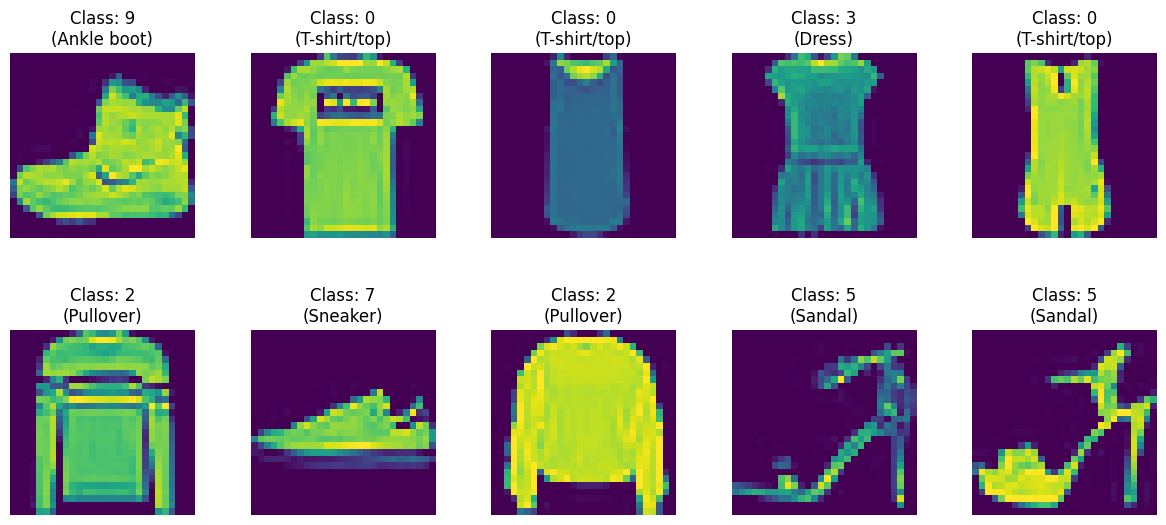

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8212 - loss: 0.5046 - val_accuracy: 0.8565 - val_loss: 0.3914
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8648 - loss: 0.3719 - val_accuracy: 0.8643 - val_loss: 0.3665
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8789 - loss: 0.3315 - val_accuracy: 0.8782 - val_loss: 0.3309
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8893 - loss: 0.3048 - val_accuracy: 0.8767 - val_loss: 0.3220
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8932 - loss: 0.2889 - val_accuracy: 0.8778 - val_loss: 0.3242
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8988 - loss: 0.2732 - val_accuracy: 0.8775 - val_loss: 0.3431
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9020 - loss: 0.2592 - val_accuracy: 0.8770 - val_loss: 0.3481
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9063 - loss: 0.

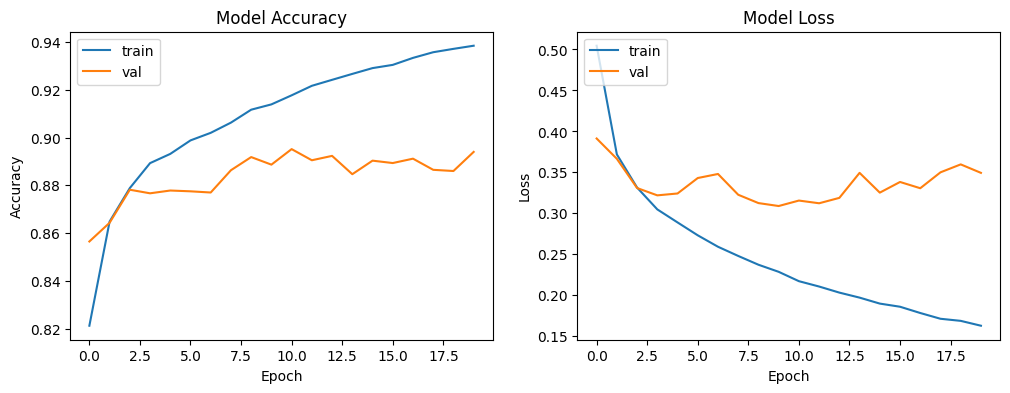

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Kết quả dự đoán thử nghiệm ---
Ảnh số 0 - Dự đoán: 9 | Thực tế (True label): 9
Ảnh số 10 - Dự đoán: 4 | Thực tế (True label): 4


In [1]:
# ==========================================
# 1. NẠP THƯ VIỆN KHỞI TẠO
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 2. TẢI VÀ ĐỌC TẬP DỮ LIỆU FASHION MNIST
# ==========================================
# Tải bộ dữ liệu tích hợp sẵn trong TensorFlow
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

print("Kích thước dữ liệu gốc:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}\n")

# Định nghĩa 10 nhãn tương ứng của tập dữ liệu để trực quan hóa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 3. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
# Reshape dữ liệu từ ma trận ảnh 3D (28x28) thành mảng phẳng 2D (784 features)
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Chuẩn hóa dữ liệu về khoảng [0, 1] sử dụng MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train.astype('float32'))
X_test = minmax.transform(X_test.astype('float32'))

print("Kích thước dữ liệu sau khi phẳng hóa (Reshape):")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}\n")
print('Số lượng lớp (Classes):', len(np.unique(y_train)))
print('Các nhãn lớp:', np.unique(y_train))

# ==========================================
# 4. TRỰC QUAN HÓA DỮ LIỆU (Hiển thị 10 hình ảnh đầu tiên)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    # Trả lại hình dạng ảnh 28x28 để hiển thị hình ảnh đồ họa
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='viridis')
    ax[i].set_title(f"Class: {y_train[i]}\n({class_names[y_train[i]]})")
    ax[i].axis('off') # Ẩn các trục tọa độ cho đẹp

plt.subplots_adjust(hspace=0.5)
plt.show()

# ==========================================
# 5. XÂY DỰNG KIẾN TRÚC MÔ HÌNH ANN
# ==========================================
fashion_model = Sequential()

# Thêm tầng Hidden Layer đầu tiên: 256 neuron, hàm kích hoạt ReLU
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256,
                        kernel_initializer='uniform', activation='relu'))

# Thêm tầng Output Layer: 10 neuron (do có 10 lớp), hàm kích hoạt Softmax để tính xác suất
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình (Compile)
fashion_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Xem cấu trúc tổng quan của mạng
fashion_model.summary()

# ==========================================
# 6. HUẤN LUYỆN MÔ HÌNH (Train Model)
# ==========================================
# Trích ra 10% (validation_split=0.1) từ tập train để làm tập kiểm thử (Validation) trong khi học
model_fit = fashion_model.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=20,
                              batch_size=32,
                              verbose=1)

# ==========================================
# 7. ĐÁNH GIÁ MÔ HÌNH BẰNG ĐỒ THỊ
# ==========================================
# Đồ thị biểu diễn độ chính xác (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Đồ thị biểu diễn độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.show()

# ==========================================
# 8. DỰ BÁO ẢNH MỚI TRÊN TẬP TEST
# ==========================================
predictions = fashion_model.predict(X_test)

print("\n--- Kết quả dự đoán thử nghiệm ---")
print(f"Ảnh số 0 - Dự đoán: {np.argmax(predictions[0])} | Thực tế (True label): {y_test[0]}")
print(f"Ảnh số 10 - Dự đoán: {np.argmax(predictions[10])} | Thực tế (True label): {y_test[10]}")

Đọc file từ drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-> Đã kết nối Drive và tìm thấy các file dữ liệu thành công!

--- 5 dòng đầu tiên của tập Train ---
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      6     104      29      16     112      61      83     111     216   
1      3     189     209     216     224     110     103      59     170   
2      7     220      21     195     147      95     227     241      67   
3      4     175      36     142     162     219     198     159      10   
4      6      49       2     204     106     112      93     253     117   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0      85  ...       199        22        46        89        45       106   
1     203  ...        73       232       223       225        62       155   
2     218  ...       174        48       226       107       225       160   
3 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1022 - loss: 2.3389 - val_accuracy: 0.0800 - val_loss: 2.3488
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1067 - loss: 2.3159 - val_accuracy: 0.1400 - val_loss: 2.2826
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1467 - loss: 2.2503 - val_accuracy: 0.1400 - val_loss: 2.3289
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2378 - loss: 2.2136 - val_accuracy: 0.1400 - val_loss: 2.3240
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1889 - loss: 2.2219 - val_accuracy: 0.1200 - val_loss: 2.3418
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2422 - loss: 2.1618 - val_accuracy: 0.1000 - val_loss: 2.2742
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2533 - loss: 2.0951 - val_accuracy: 0.1200 - val_loss: 2.3520
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3089 - loss: 2.

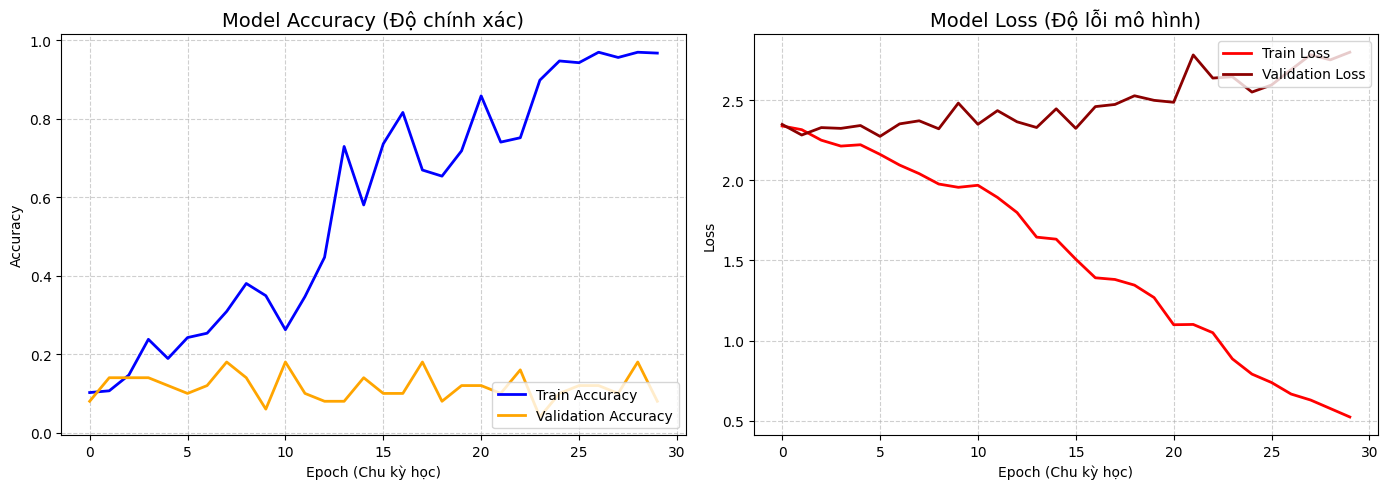


--- Kết quả dự báo thử nghiệm ---
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Giá trị mô hình dự đoán: 6 | Giá trị nhãn thực tế: 5


In [9]:
# =====================================================================
# 1. KẾT NỐI GOOGLE DRIVE VÀ NẠP CÁC THƯ VIỆN
# =====================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Kết nối tới Google Drive của bạn
drive.mount('/content/drive')

# Cấu hình đường dẫn chính xác tới thư mục chứa file trong Drive của bạn
# 'MyDrive' tương ứng với thư mục "Drive của tôi", theo sau là tên các thư mục con
folder_path = '/content/drive/MyDrive/thDeepLearning/tuan2/'

mnist_train_path = os.path.join(folder_path, 'fashion-mnist_train.csv')
mnist_test_path = os.path.join(folder_path, 'fashion-mnist_test.csv')

# Kiểm tra xem các file có tồn tại hay không trước khi thực hiện đọc dữ liệu
if not os.path.exists(mnist_train_path):
    raise FileNotFoundError(f"Không tìm thấy file Train tại: {mnist_train_path}. Bạn hãy kiểm tra lại tên thư mục và tên file trên Drive nhé!")
if not os.path.exists(mnist_test_path):
    raise FileNotFoundError(f"Không tìm thấy file Test tại: {mnist_test_path}. Bạn hãy kiểm tra lại tên thư mục và tên file trên Drive nhé!")

print("-> Đã kết nối Drive và tìm thấy các file dữ liệu thành công!\n")

# =====================================================================
# 2. ĐỌC TẬP DỮ LIỆU BẰNG THƯ VIỆN PANDAS (MỤC 3.9 TRONG LAB)
# =====================================================================
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print("--- 5 dòng đầu tiên của tập Train ---")
print(mnist_train.head())
print("\nKích thước tập Train gốc từ Drive:", mnist_train.shape)

# =====================================================================
# 3. PHÂN TÁCH ĐẶC TRƯNG (X) VÀ NHÃN (Y)
# =====================================================================
# Cột đầu tiên là 'label' (nhãn lớp), các cột từ chỉ số 1 trở đi là 784 điểm ảnh (features)
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print("\nKích thước ma trận đặc trưng X_train:", X_train.shape)
print('Số lượng phân lớp dữ liệu:', len(np.unique(y_train)))
print('Danh sách các nhãn lớp:', np.unique(y_train))

# =====================================================================
# 4. TIỀN XỬ LÝ DỮ LIỆU (FEATURE SCALING KHÚC NÀY)
# =====================================================================
# Chuyển đổi dữ liệu từ dạng DataFrame sang mảng Numpy float32
X_train = X_train.values.astype('float32')
X_test = X_test.values.astype('float32')

# Áp dụng bộ chuẩn hóa Max-Min (đưa các giá trị điểm ảnh 0-255 về khoảng 0-1)
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train) # Tìm min, max trên tập Train rồi chuẩn hóa
X_test = minmax.transform(X_test)       # Chuẩn hóa tập Test theo min, max của tập Train

# =====================================================================
# 5. KHỞI TẠO CẤU TRÚC MÔ HÌNH MẠNG NEURAL (ANN)
# =====================================================================
model = Sequential()

# Thêm tầng Ẩn (Hidden Layer): 256 neuron, nhận đầu vào có kích thước 784, hàm kích hoạt relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm tầng Đầu ra (Output Layer): 10 neuron đại diện cho 10 lớp phân loại trang phục, hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng Neural
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# =====================================================================
# 6. HUẤN LUYỆN MÔ HÌNH VỚI 30 EPOCHS (LƯU LỊCH SỬ VÀO BIẾN MODEL_FIT)
# =====================================================================
print("\n--- Bắt đầu huấn luyện mô hình ---")
model_fit = model.fit(X_train, y_train,
                        validation_split=0.1, # Trích 10% ra làm tập Validation kiểm định khi học
                        epochs=30,
                        batch_size=32,
                        verbose=1)

# =====================================================================
# 7. KHÚC VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị trái: Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác)', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Epoch (Chu kỳ học)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị phải: Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=14)
plt.ylabel('Loss')
plt.xlabel('Epoch (Chu kỳ học)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# 8. DỰ BÁO NHÃN TRÊN MẪU THỬ NGHIỆM ĐẦU TIÊN
# =====================================================================
print("\n--- Kết quả dự báo thử nghiệm ---")
prediction_0 = np.argmax(model.predict(X_test)[0])
print(f"Giá trị mô hình dự đoán: {prediction_0} | Giá trị nhãn thực tế: {y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0]}")

Đọc dữ liệu từ file

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Bắt đầu quá trình huấn luyện mạng ANN ---
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2765 - loss: 1.6201 - val_accuracy: 0.5600 - val_loss: 1.4172
Epoch 2/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5392 - loss: 1.3811 - val_accuracy: 0.6800 - val_loss: 1.1733
Epoch 3/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5668 - loss: 1.2414 - val_accuracy: 0.6800 - val_loss: 1.0208
Epoch 4/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5668 - loss: 1.1483 - val_accuracy: 0.6800 - val_loss: 0.9177
Epoch 5/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5714 - loss: 1.0993 - val_accuracy: 0.6800 - val_loss: 0.8692
Epoch 6/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5991 - loss: 1.0300 - val_accuracy: 0.6800 - val_loss: 0.8430
Epoch 7/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6267 - loss: 0.9974 - val_accuracy: 0.6800 - val_loss: 0.8287
Epoch 8/60
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6313 - loss: 0.9659 - val_accuracy: 0.6800 - val_loss: 0.8037
Ep

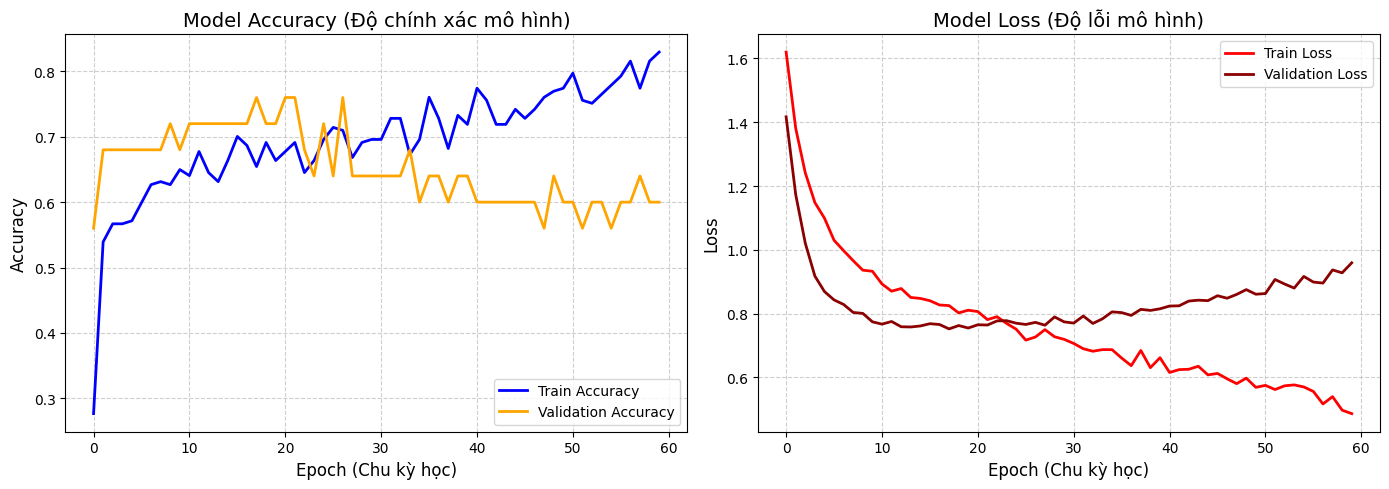


[KẾT QUẢ TỔNG KẾT] Độ chính xác trên tập Test: 55.74%


In [10]:
# =====================================================================
# 1. KẾT NỐI GOOGLE DRIVE VÀ NẠP THƯ VIỆN
# =====================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt  # Thư viện để vẽ đồ thị

# Kết nối tới Google Drive của bạn
drive.mount('/content/drive')

# Đường dẫn tới file csv trên Google Drive của bạn

mnist_train_path = os.path.join(folder_path, 'fashion-mnist_train.csv')
file_path = '/content/drive/MyDrive/thDeepLearning/tuan2/heart_disease_dataset.csv'

# Kiểm tra file tồn tại
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Không tìm thấy file tại đường dẫn: {file_path}. Hãy kiểm tra lại vị trí lưu file.")

# =====================================================================
# 2. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU CHỮ / SỐ
# =====================================================================
df = pd.read_csv(file_path)

# Bước A: Xử lý giá trị khuyết thiếu (nếu có ô trống thì điền bằng giá trị phổ biến nhất)
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Bước B: One-Hot Encoding chuyển đổi dữ liệu chữ (sex, cp, fbs, thal) sang số
df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'thal'], drop_first=True)

# Bước C: Tách Đặc trưng (X) và Nhãn mục tiêu (y)
X = df_encoded.drop(columns=['state'])
y = df_encoded['state']

# Bước D: Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bước E: Chuẩn hóa dữ liệu về cùng một phân phối bằng StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ... [Khúc đọc file và chuyển chữ thành số One-Hot Encoding ở trên] ...

# Khúc chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# KHÚC SỬ DỤNG MAX-MIN SCALER (MINMAXSCALER)
# =====================================================================
from sklearn.preprocessing import MinMaxScaler

# 1. Khởi tạo bộ gom Max-Min
minmax_scaler = MinMaxScaler()

# 2. Vừa học thông số Max, Min vừa biến đổi tập Train
X_train = minmax_scaler.fit_transform(X_train)

# 3. Chỉ biến đổi tập Test theo khung thông số Max, Min của tập Train
X_test = minmax_scaler.transform(X_test)
# =====================================================================


# =====================================================================
# 3. XÂY DỰNG KIẾN TRÚC MẠNG NEURAL (ANN)
# =====================================================================
num_classes = len(np.unique(y))  # Số lượng lớp (mức độ bệnh từ 0 đến 4 -> 5 lớp)

model_heart = Sequential()
model_heart.add(Dense(units=64, input_dim=X_train.shape[1], activation='relu'))
model_heart.add(Dropout(0.2))  # Giảm overfitting
model_heart.add(Dense(units=32, activation='relu'))
model_heart.add(Dense(units=num_classes, activation='softmax'))

model_heart.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# =====================================================================
# 4. TIẾN HÀNH HUẤN LUYỆN MÔ HÌNH (Lưu lịch sử vào biến `model_fit`)
# =====================================================================
print("\n--- Bắt đầu quá trình huấn luyện mạng ANN ---")
# Trích ra 10% dữ liệu từ tập Train để làm tập kiểm định (Validation) trong khi học
model_fit = model_heart.fit(X_train, y_train,
                              validation_split=0.1,
                              epochs=60,
                              batch_size=16,
                              verbose=1)

# =====================================================================
# 5. VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (ACCURACY) VÀ ĐỘ LỖI (LOSS)
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị 1: Biển diễn Độ chính xác (Model Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác mô hình)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch (Chu kỳ học)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị 2: Biểu diễn Độ lỗi (Model Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch (Chu kỳ học)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị đồ thị lên màn hình Colab
plt.tight_layout()
plt.show()

# =====================================================================
# 6. ĐÁNH GIÁ TRÊN TẬP DỮ LIỆU TEST ĐỘC LẬP
# =====================================================================
test_loss, test_acc = model_heart.evaluate(X_test, y_test, verbose=0)
print(f"\n[KẾT QUẢ TỔNG KẾT] Độ chính xác trên tập Test: {test_acc*100:.2f}%")

Lấy ảnh và so sánh với kho huấn luyện đề xác định hình ảnh là gì

Đang nạp bộ dữ liệu đầy đủ (70.000 ảnh) từ Keras Datasets...
-> Số lượng ảnh tập Train: 60000 ảnh (Kích thước: 28x28)
-> Số lượng ảnh tập Test: 10000 ảnh

[HIỂN THỊ] Hình ảnh trích xuất từ bộ dữ liệu mang nhãn: Ankle boot


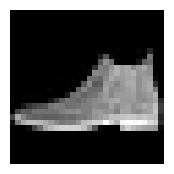

-> Đã tạo xong file ảnh thực tế lưu tại: /content/sample_data/fashion_heavy_image.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ANN với dải dữ liệu lớn ---
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8141 - loss: 0.5365 - val_accuracy: 0.8528 - val_loss: 0.4118
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8607 - loss: 0.3898 - val_accuracy: 0.8700 - val_loss: 0.3658
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8765 - loss: 0.3458 - val_accuracy: 0.8673 - val_loss: 0.3557
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8858 - loss: 0.3163 - val_accuracy: 0.8750 - val_loss: 0.3456
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8907 - loss: 0.2987 - val_accuracy: 0.8823 - val_loss: 0.3250
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8968 - loss: 0.2828 - val_accuracy: 0.8825 - val_loss: 0.3210
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9027 - loss: 0.2664 - val_accuracy: 0.8752 - val_loss: 0.3548
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 

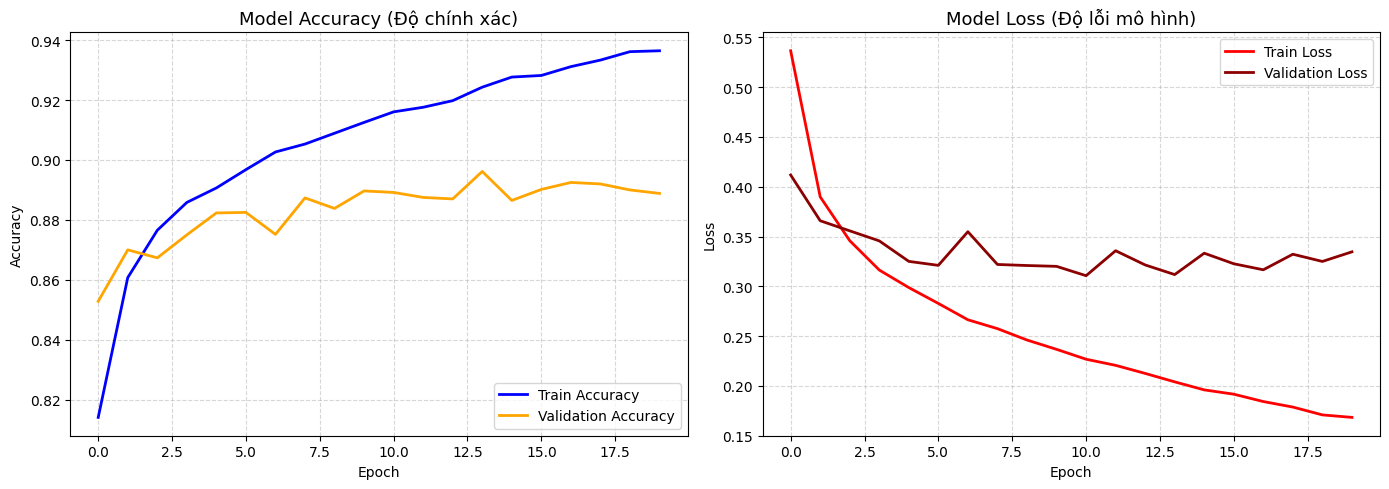


--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ BẰNG KERAS IMAGE ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp:
 [[1.1845563e-08 8.0241411e-11 7.7011236e-15 2.9483008e-13 3.5423608e-11
  2.4848720e-07 3.9211723e-10 7.6214805e-05 6.2428090e-11 9.9992347e-01]]

[KẾT QUẢ TỔNG HỢP SAU KHI DỰ ĐOÁN]:
-> Tên nhãn thực tế của bức ảnh trích xuất: 9 (Ankle boot)
-> Tên nhãn mô hình ANN sử dụng Keras Image dự đoán: 9 (Ankle boot)


In [17]:
# =====================================================================
# BƯỚC 1: NẠP TOÀN BỘ 70.000 ẢNH TỪ KERAS VÀ XUẤT ẢNH THỰC TẾ
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Tạo thư mục sample_data trên bộ nhớ tạm của Colab
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang nạp bộ dữ liệu đầy đủ (70.000 ảnh) từ Keras Datasets...")
# Tải bộ dữ liệu Fashion MNIST chính thức với số lượng ảnh tối đa
(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"-> Số lượng ảnh tập Train: {X_train_raw.shape[0]} ảnh (Kích thước: {X_train_raw.shape[1]}x{X_train_raw.shape[2]})")
print(f"-> Số lượng ảnh tập Test: {X_test_raw.shape[0]} ảnh")

# Định nghĩa danh sách tên 10 lớp trang phục thời trang
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Lấy ngẫu nhiên bức ảnh đầu tiên từ tập Test để lưu thành file ảnh vật lý kiểm thử
sample_matrix = X_test_raw[0]
actual_label = y_test[0]

# Hiển thị trực quan bức ảnh mẫu này lên màn hình Colab
print(f"\n[HIỂN THỊ] Hình ảnh trích xuất từ bộ dữ liệu mang nhãn: {class_names[actual_label]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix, cmap='gray')
plt.axis('off')
plt.show()

# Lưu ma trận ảnh này thành một file ảnh vật lý thực sự tên là 'fashion_heavy_image.jpg'
test_image_path = '/content/sample_data/fashion_heavy_image.jpg'
plt.imsave(test_image_path, sample_matrix, cmap='gray')
print(f"-> Đã tạo xong file ảnh thực tế lưu tại: {test_image_path}\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ CHUẨN HÓA DỮ LIỆU (DUỠI PHẲNG VECTOR & MAX-MIN SCALER)
# =====================================================================
# Vì ảnh gốc là ma trận 2D (28x28), ta cần duỗi phẳng (flatten) thành dạng hàng dọc 1D (784,)
# để tương thích với cấu trúc các tầng Dense Layer của mạng ANN (Mục 3.9)
X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype('float32')

# Áp dụng bộ MinMaxScaler đưa giá trị pixel từ dải [0-255] về khoảng [0-1]
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN) (MỤC 3.9)
# =====================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Tầng Ẩn (Hidden Layer): 256 neuron kết nối đầy đủ, dùng hàm kích hoạt relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng Đầu ra (Output Layer): 10 lớp phân loại tương ứng với 10 loại trang phục, hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch cấu trúc mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình ANN với dải dữ liệu lớn ---")
# Huấn luyện mô hình và lưu tiến trình vào biến model_fit để vẽ đồ thị
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)


# =====================================================================
# BƯỚC 4: VẼ ĐỒ THỊ HIỆU NĂNG MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị hiển thị Model Accuracy qua từng chu kỳ Epoch
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị hiển thị Model Loss qua từng chu kỳ Epoch
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# BƯỚC 5: ĐOẠN ĐỌC FILE ẢNH VÀ TIỀN XỬ LÝ DỰ ĐOÁN (TF.KERAS.PREPROCESSING.IMAGE)
# =====================================================================
print("\n--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ BẰNG KERAS IMAGE ---")

# 1. Định nghĩa kích thước ảnh cần mẫu về dải vuông 28x28
img_size = (28, 28)

# 2. Tải ảnh từ đường dẫn cụ thể (Đọc file ảnh thực tế đã được xuất ra ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    test_image_path,
    color_mode="grayscale",
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh 2D thành Vector phẳng 1D (784,) để khớp với tầng đầu vào
img_flat = np.reshape(img_array, (784,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 784) phù hợp yêu cầu đầu vào của Keras khi predict
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp:\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất cao nhất (argmax) để xuất ra kết quả phân loại cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ TỔNG HỢP SAU KHI DỰ ĐOÁN]:")
print(f"-> Tên nhãn thực tế của bức ảnh trích xuất: {actual_label} ({class_names[actual_label]})")
print(f"-> Tên nhãn mô hình ANN sử dụng Keras Image dự đoán: {score} ({class_names[score]})")

Bài tập 1

Đang nạp bộ dữ liệu ảnh màu CIFAR10 trực tiếp từ Keras Datasets...
-> Kích thước tập Train gốc: (50000, 32, 32, 3)
-> Kích thước tập Test gốc: (10000, 32, 32, 3)

[HIỂN THỊ] Hình ảnh mẫu trích xuất từ bộ dữ liệu mang nhãn: Cat


/tmp/ipykernel_4701/1496737233.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_label = int(y_test_raw[0])


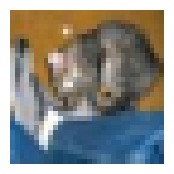

-> Đã tạo xong file ảnh thực tế phục vụ dự đoán tại: /content/sample_data/cifar10_test_image.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ANN trong 20 Epochs ---
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3249 - loss: 1.8782 - val_accuracy: 0.3592 - val_loss: 1.7888
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3959 - loss: 1.6948 - val_accuracy: 0.3756 - val_loss: 1.7230
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4218 - loss: 1.6286 - val_accuracy: 0.4150 - val_loss: 1.6457
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4392 - loss: 1.5806 - val_accuracy: 0.4410 - val_loss: 1.5742
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4484 - loss: 1.5525 - val_accuracy: 0.4110 - val_loss: 1.6479
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4575 - loss: 1.5280 - val_accuracy: 0.4576 - val_loss: 1.5308
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4698 - loss: 1.5041 - val_accuracy: 0.4472 - val_loss: 1.5793
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━

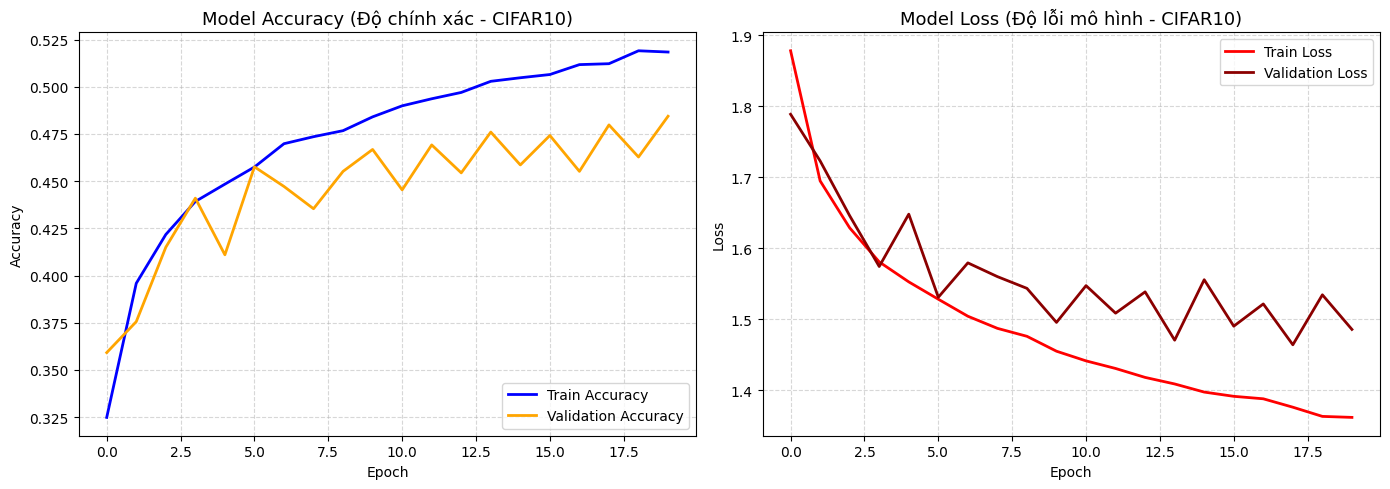


--- BẮT ĐẦU QUÁ TRÌNH TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp vật thể:
 [[4.0201470e-02 3.1221297e-03 1.6274238e-01 3.7559539e-01 6.5608107e-02
  1.0750237e-01 2.3364700e-01 5.2560976e-04 1.0798853e-02 2.5678423e-04]]

[KẾT QUẢ ĐỐI CHIẾU]:
-> Tên nhãn thực tế lưu trong bộ dữ liệu gốc: 3 (Cat)
-> Tên nhãn mô hình mạng ANN dùng Keras Image dự đoán: 3 (Cat)


In [19]:
# =====================================================================
# 1. NẠP BỘ DỮ LIỆU ĐẦY ĐỦ TỪ TENSORFLOW & KHỞI TẠO ẢNH KIỂM THỬ
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Tạo thư mục tạm để chứa ảnh mẫu kiểm thử trên Colab
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang nạp bộ dữ liệu ảnh màu CIFAR10 trực tiếp từ Keras Datasets...")
# Tải bộ dữ liệu chính thức từ máy chủ TensorFlow
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

print(f"-> Kích thước tập Train gốc: {X_train_raw.shape}")
print(f"-> Kích thước tập Test gốc: {X_test_raw.shape}")

# Tên 10 nhãn tương ứng theo thứ tự từ 0 đến 9 của bộ dữ liệu CIFAR10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Lấy ngẫu nhiên bức ảnh đầu tiên (index 0) trong tập Test để xuất ra file ảnh .jpg
sample_matrix = X_test_raw[0]
actual_label = int(y_test_raw[0])

# Hiển thị trực quan bức ảnh mẫu này lên màn hình Colab
print(f"\n[HIỂN THỊ] Hình ảnh mẫu trích xuất từ bộ dữ liệu mang nhãn: {class_names[actual_label]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix)
plt.axis('off')
plt.show()

# Lưu ma trận ảnh màu này thành file ảnh thực tế 'cifar10_test_image.jpg' để làm đầu vào cho load_img
test_image_path = '/content/sample_data/cifar10_test_image.jpg'
plt.imsave(test_image_path, sample_matrix)
print(f"-> Đã tạo xong file ảnh thực tế phục vụ dự đoán tại: {test_image_path}\n")


# =====================================================================
# 2. TIỀN XỬ LÝ CHUẨN HÓA DỮ LIỆU (DUỠI PHẲNG MẠNG VÀ MAX-MIN SCALER)
# =====================================================================
# Ảnh màu CIFAR10 có kích thước 3D: 32x32x3 (3 kênh màu Đỏ-Xanh lá-Xanh dương)
# Mạng ANN chỉ nhận vector phẳng 1D đầu vào, nên ta cần duỗi thẳng: 32 * 32 * 3 = 3072 thuộc tính
X_train = X_train_raw.reshape(X_train_raw.shape[0], 3072).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 3072).astype('float32')

# Chuyển đổi mảng nhãn y về dạng mảng phẳng 1 chiều
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

# Chuẩn hóa dải giá trị điểm ảnh từ [0-255] về dải số thực [0-1] bằng MinMaxScaler
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# 3. XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN)
# =====================================================================
model = Sequential()

# Tầng ẩn (Hidden Layer): Đầu vào input_dim là 3072 nút, tầng gồm 256 neuron, hàm kích hoạt relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng đầu ra (Output Layer): 10 neuron đại diện cho 10 lớp vật thể, hàm kích hoạt softmax tính xác suất
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình ANN trong 20 Epochs ---")
# Huấn luyện mô hình và trích 10% làm tập validation kiểm định trong lúc học
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)


# =====================================================================
# 4. VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị biểu diễn Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác - CIFAR10)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị biểu diễn Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình - CIFAR10)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# 5. TIỀN XỬ LÝ VÀ DỰ ĐOÁN ẢNH ĐƠN LẺ (DÙNG TF.KERAS.PREPROCESSING.IMAGE)
# =====================================================================
print("\n--- BẮT ĐẦU QUÁ TRÌNH TIỀN XỬ LÝ VÀ DỰ ĐOÁN FILE ẢNH ĐƠN LẺ ---")

# 1. Định nghĩa kích thước ảnh màu cần resize về dải vuông 32x32 của bộ dữ liệu
img_size = (32, 32)

# 2. Tải ảnh từ đường dẫn cụ thể (Đọc file ảnh .jpg vừa được xuất ra ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    test_image_path,
    color_mode="rgb",  # CHÚ Ý: Đổi thành "rgb" vì dữ liệu ảnh màu CIFAR10 gồm 3 kênh màu
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh (PIL image) thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh màu 3D thành Vector phẳng 1D (3072,) để khớp với tầng đầu vào
img_flat = np.reshape(img_array, (3072,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 3072) phù hợp yêu cầu hàm predict của Keras
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 lớp vật thể:\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất lớn nhất (argmax) để xuất ra màn hình kết quả cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ ĐỐI CHIẾU]:")
print(f"-> Tên nhãn thực tế lưu trong bộ dữ liệu gốc: {actual_label} ({class_names[actual_label]})")
print(f"-> Tên nhãn mô hình mạng ANN dùng Keras Image dự đoán: {score} ({class_names[score]})")

Bài tập 2

Đang nạp bộ dữ liệu chữ số viết tay MNIST từ Keras Datasets...
-> Kích thước tập dữ liệu Train gốc: (60000, 28, 28)
-> Kích thước tập dữ liệu Test gốc: (10000, 28, 28)

[HIỂN THỊ] Đã chọn bức ảnh tại vị trí index 59, mang nhãn thực tế là: Số 5


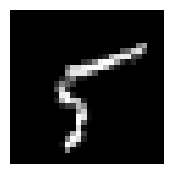

-> Đã tạo xong file ảnh vật lý mới phục vụ dự đoán tại: /content/sample_data/mnist_another_digit.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình mạng ANN nhận dạng chữ số trong 15 Epochs ---
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9103 - loss: 0.3224 - val_accuracy: 0.9637 - val_loss: 0.1339
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9609 - loss: 0.1346 - val_accuracy: 0.9717 - val_loss: 0.0973
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9734 - loss: 0.0895 - val_accuracy: 0.9760 - val_loss: 0.0844
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9806 - loss: 0.0653 - val_accuracy: 0.9777 - val_loss: 0.0756
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9850 - loss: 0.0502 - val_accuracy: 0.9822 - val_loss: 0.0677
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9887 - loss: 0.0382 - val_accuracy: 0.9782 - val_loss: 0.0749
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9913 - loss: 0.0292 - val_accuracy: 0.9815 - val_loss: 0.0686
Epoch 8/15
844/844 ━━━━━━

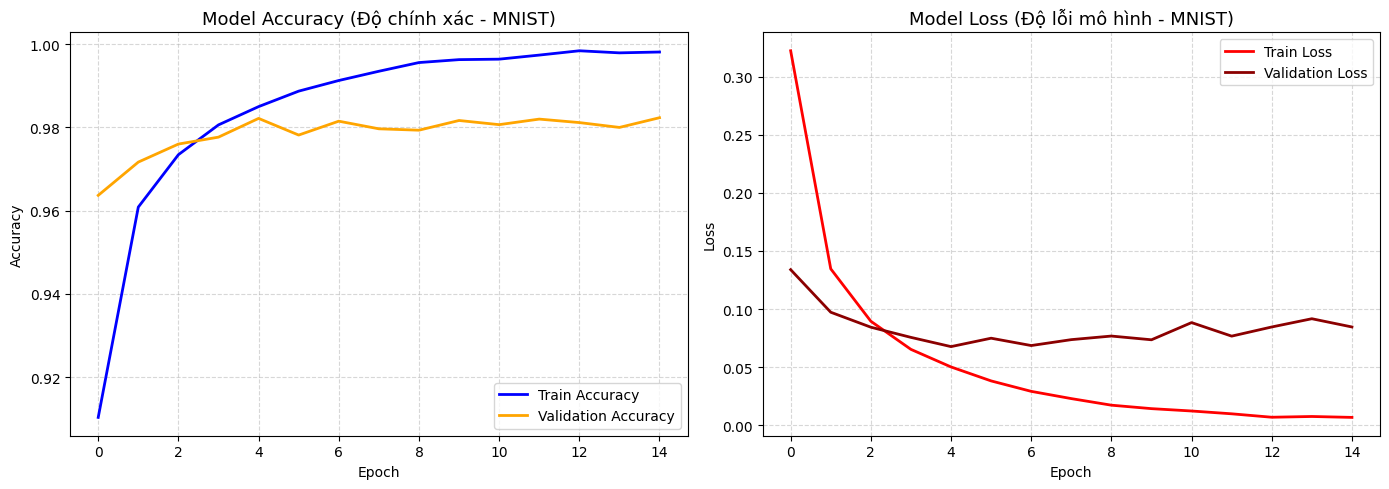


--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN BỨC ẢNH VẬT LÝ MỚI CHỌN ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 chữ số (từ 0 đến 9):
 [[6.2040407e-08 1.8318648e-09 3.7832601e-10 8.2536966e-10 4.2492709e-10
  9.9984550e-01 2.5961705e-10 8.3622472e-05 6.9453177e-05 1.2427088e-06]]

[KẾT QUẢ ĐỐI CHIẾU NHẬN DẠNG CHỮ SỐ KHÁC]:
-> Chữ số thực tế của bức ảnh được chọn (index 59): 5 (Số 5)
-> Chữ số mô hình mạng ANN dùng Keras Image dự đoán: 5 (Số 5)


In [29]:
# =====================================================================
# 1. NẠP DỮ LIỆU ĐẦY ĐỦ VÀ TRÍCH XUẤT MỘT ẢNH MẪU KHÁC (BẤT KỲ)
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Tạo thư mục tạm trên Colab để lưu file ảnh kiểm thử
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang nạp bộ dữ liệu chữ số viết tay MNIST từ Keras Datasets...")
# Tải bộ dữ liệu chữ số viết tay chính thức từ TensorFlow
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

print(f"-> Kích thước tập dữ liệu Train gốc: {X_train_raw.shape}")
print(f"-> Kích thước tập dữ liệu Test gốc: {X_test_raw.shape}")

# Định nghĩa danh sách tên các nhãn chữ số (từ Số 0 đến Số 9)
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4', 'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# CHỌN MỘT BỨC ẢNH KHÁC (TỰ ĐỘNG CHỌN INDEX 59 HOẶC NGẪU NHIÊN TRONG KHO 10.000 ẢNH TEST)
# Thay vì lấy [0], bạn có thể thay số khác từ 0 đến 9999
index_cua_anh_khac = 59
sample_matrix_khac = X_test_raw[index_cua_anh_khac]
actual_label_khac = y_test_raw[index_cua_anh_khac]

# Hiển thị trực quan bức ảnh chữ số viết tay mới được chọn này
print(f"\n[HIỂN THỊ] Đã chọn bức ảnh tại vị trí index {index_cua_anh_khac}, mang nhãn thực tế là: {class_names[actual_label_khac]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix_khac, cmap='gray')
plt.axis('off')
plt.show()

# Lưu ma trận ảnh xám này thành file ảnh vật lý mới mang tên 'mnist_another_digit.jpg'
another_image_path = '/content/sample_data/mnist_another_digit.jpg'
plt.imsave(another_image_path, sample_matrix_khac, cmap='gray')
print(f"-> Đã tạo xong file ảnh vật lý mới phục vụ dự đoán tại: {another_image_path}\n")


# =====================================================================
# 2. TIỀN XỬ LÝ CHUẨN HÓA DỮ LIỆU (DUỠI PHẲNG MẠNG VÀ MAX-MIN SCALER)
# =====================================================================
# Duỗi phẳng ma trận ảnh 2D (28x28) thành vector phẳng 1D (784,)
X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype('float32')

# Chuyển đổi nhãn về dạng phẳng 1 chiều
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

# Áp dụng MinMaxScaler để đưa giá trị pixel về khoảng số thực [0-1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# 3. XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN)
# =====================================================================
model = Sequential()

# Tầng ẩn (Hidden Layer): Đầu vào input_dim là 784, tầng chứa 256 neuron, dùng hàm relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng đầu ra (Output Layer): 10 neuron đại diện cho 10 chữ số từ 0-9, dùng hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch cấu trúc mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình mạng ANN nhận dạng chữ số trong 15 Epochs ---")
# Huấn luyện mô hình và trích 10% làm tập validation chấm điểm kiểm định khi đang học
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=15, batch_size=64, verbose=1)


# =====================================================================
# 4. KHÚC VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị hiển thị Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác - MNIST)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị hiển thị Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình - MNIST)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# 5. ĐOẠN ĐỌC FILE ẢNH VÀ TIỀN XỬ LÝ DỰ ĐOÁN (DÙNG FILE ẢNH MỚI)
# =====================================================================
print("\n--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN BỨC ẢNH VẬT LÝ MỚI CHỌN ---")

# 1. Định nghĩa kích thước ảnh mẫu về dải vuông 28x28 của bộ dữ liệu MNIST
img_size = (28, 28)

# 2. Tải ảnh từ đường dẫn cụ thể (Đọc file ảnh .jpg KHÁC đã được xuất ra ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    another_image_path,
    color_mode="grayscale",
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh (PIL image) thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh vuông 2D về Vector phẳng 1D (784,)
img_flat = np.reshape(img_array, (784,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 784) phù hợp yêu cầu hàm predict
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo mảng xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 chữ số (từ 0 đến 9):\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất lớn nhất (argmax) để xuất ra kết quả chữ số dự đoán cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ ĐỐI CHIẾU NHẬN DẠNG CHỮ SỐ KHÁC]:")
print(f"-> Chữ số thực tế của bức ảnh được chọn (index {index_cua_anh_khac}): {actual_label_khac} ({class_names[actual_label_khac]})")
print(f"-> Chữ số mô hình mạng ANN dùng Keras Image dự đoán: {score} ({class_names[score]})")

Đang nạp bộ dữ liệu chữ số viết tay MNIST từ Keras Datasets...

[HIỂN THỊ] Ngẫu nhiên chọn ảnh tại index 768 | Nhãn thực tế: Số 1


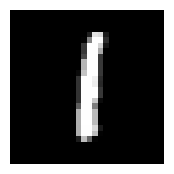

-> Đã tạo xong file ảnh vật lý ngẫu nhiên tại: /content/sample_data/mnist_random_digit.jpg



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình mạng ANN nhận dạng chữ số ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9106 - loss: 0.3226 - val_accuracy: 0.9630 - val_loss: 0.1416
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9615 - loss: 0.1333 - val_accuracy: 0.9713 - val_loss: 0.0978
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9744 - loss: 0.0879 - val_accuracy: 0.9748 - val_loss: 0.0887
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9806 - loss: 0.0639 - val_accuracy: 0.9790 - val_loss: 0.0766
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9848 - loss: 0.0496 - val_accuracy: 0.9750 - val_loss: 0.0910
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9886 - loss: 0.0373 - val_accuracy: 0.9805 - val_loss: 0.0708
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0292 - val_accuracy: 0.9835 - val_loss: 0.0679
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s

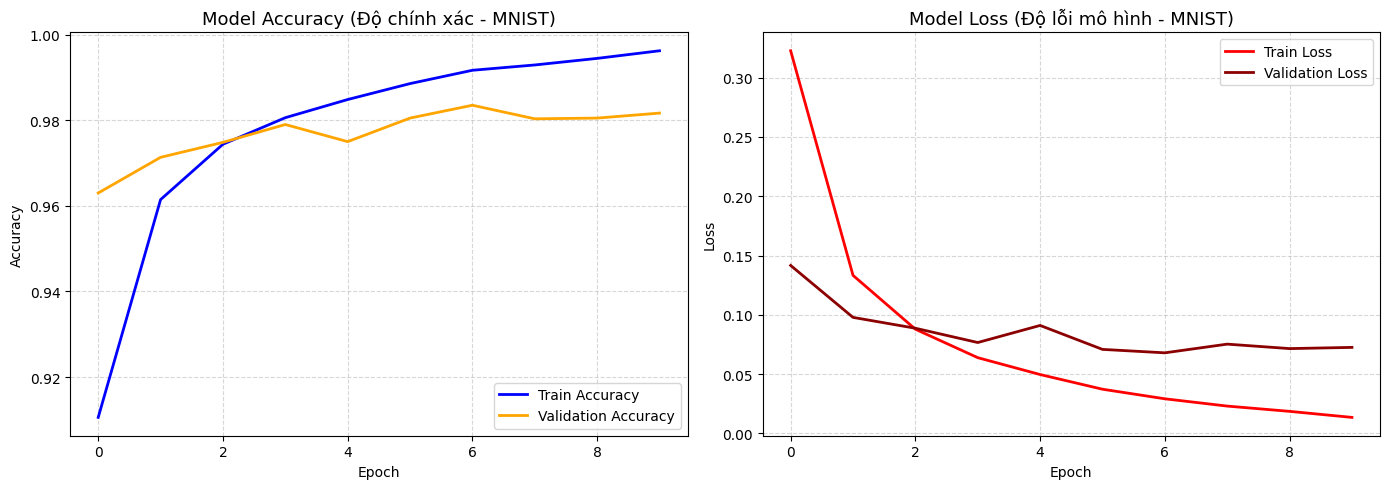


--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN BỨC ẢNH NGẪU NHIÊN VỪA CHỌN ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Mảng tỷ lệ phần trăm xác suất dự đoán của 10 chữ số (từ 0 đến 9):
 [[2.5219937e-10 9.9951208e-01 1.4231563e-07 1.3951995e-06 2.6451085e-07
  1.3755181e-08 4.7017943e-06 4.2169179e-07 4.8095567e-04 7.8247844e-09]]

[KẾT QUẢ ĐỐI CHIẾU NHẬN DẠNG ẢNH NGẪU NHIÊN]:
-> Chữ số thực tế gốc tại index 768: 1 (Số 1)
-> Chữ số mô hình mạng ANN dùng Keras Image dự đoán: 1 (Số 1)


In [28]:
# =====================================================================
# BƯỚC 1: NẠP DỮ LIỆU ĐẦY ĐỦ VÀ TỰ ĐỘNG CHỌN 1 ẢNH NGẪU NHIÊN CHỮ SỐ
# =====================================================================
import os
import random  # Thư viện để chọn số ngẫu nhiên
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Tạo thư mục tạm trên Colab để lưu file ảnh kiểm thử
os.makedirs('/content/sample_data', exist_ok=True)

print("Đang nạp bộ dữ liệu chữ số viết tay MNIST từ Keras Datasets...")
# Tải bộ dữ liệu chữ số viết tay chính thức từ TensorFlow
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Định nghĩa danh sách tên các nhãn chữ số (từ Số 0 đến Số 9)
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4', 'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# LẤY NGẪU NHIÊN 1 INDEX TỪ 0 ĐẾN 9999 (KHO 10.000 ẢNH TEST)
index_ngau_nhien = random.randint(0, len(X_test_raw) - 1)

sample_matrix_ngau_nhien = X_test_raw[index_ngau_nhien]
actual_label_ngau_nhien = y_test_raw[index_ngau_nhien]

# Hiển thị trực quan bức ảnh chữ số viết tay ngẫu nhiên này
print(f"\n[HIỂN THỊ] Ngẫu nhiên chọn ảnh tại index {index_ngau_nhien} | Nhãn thực tế: {class_names[actual_label_ngau_nhien]}")
plt.figure(figsize=(2, 2))
plt.imshow(sample_matrix_ngau_nhien, cmap='gray')
plt.axis('off')
plt.show()

# Lưu ma trận ảnh xám này thành file ảnh vật lý mang tên 'mnist_random_digit.jpg'
random_image_path = '/content/sample_data/mnist_random_digit.jpg'
plt.imsave(random_image_path, sample_matrix_ngau_nhien, cmap='gray')
print(f"-> Đã tạo xong file ảnh vật lý ngẫu nhiên tại: {random_image_path}\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ CHUẨN HÓA DỮ LIỆU (DUỠI PHẲNG MẠNG VÀ MAX-MIN SCALER)
# =====================================================================
# Duỗi phẳng ma trận ảnh 2D (28x28) thành vector phẳng 1D (784,)
X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype('float32')
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype('float32')

# Chuyển đổi nhãn về dạng phẳng 1 chiều
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

# Áp dụng MinMaxScaler để đưa giá trị pixel về khoảng số thực [0-1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC VÀ HUẤN LUYỆN MẠNG NEURAL (ANN)
# =====================================================================
model = Sequential()

# Tầng ẩn (Hidden Layer): Đầu vào input_dim là 784, tầng chứa 256 neuron, dùng hàm relu
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Tầng đầu ra (Output Layer): 10 neuron đại diện cho 10 chữ số từ 0-9, dùng hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch cấu trúc mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Bắt đầu huấn luyện mô hình mạng ANN nhận dạng chữ số ---")
# Huấn luyện mô hình trong 10 Epochs để chạy nhanh hơn khi bạn test nhiều lần
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=1)


# =====================================================================
# BƯỚC 4: KHÚC VẼ ĐỒ THỊ MODEL ACCURACY VÀ MODEL LOSS
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị hiển thị Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy (Độ chính xác - MNIST)', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị hiển thị Model Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(model_fit.history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Model Loss (Độ lỗi mô hình - MNIST)', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# =====================================================================
# BƯỚC 5: ĐOẠN ĐỌC FILE ẢNH VÀ TIỀN XỬ LÝ DỰ ĐOÁN (MỖI LẦN LÀ 1 ẢNH KHÁC NHAU)
# =====================================================================
print("\n--- BẮT ĐẦU TIỀN XỬ LÝ VÀ DỰ ĐOÁN BỨC ẢNH NGẪU NHIÊN VỪA CHỌN ---")

# 1. Định nghĩa kích thước ảnh mẫu về dải vuông 28x28 của bộ dữ liệu MNIST
img_size = (28, 28)

# 2. Tải ảnh từ đường dẫn cụ thể (Đọc file ảnh ngẫu nhiên vừa được lưu ở Bước 1)
img = tf.keras.preprocessing.image.load_img(
    random_image_path,
    color_mode="grayscale",
    target_size=img_size
)

# 3. Chuyển đổi đối tượng ảnh thành một mảng dữ liệu Numpy Array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# 4. Chuẩn hóa giá trị điểm ảnh (Feature Scaling) về khoảng [0, 1] giống tập Train
img_array = img_array / 255.0

# 5. Duỗi mảng (Reshape) từ ma trận ảnh vuông 2D về Vector phẳng 1D (784,)
img_flat = np.reshape(img_array, (784,))

# 6. Thêm chiều Batch (Batch dimension) thành (1, 784) phù hợp yêu cầu hàm predict
img_batch = tf.expand_dims(img_flat, axis=0)

# 7. Đưa vào mô hình mạng ANN đã được huấn luyện xong ở trên để dự báo mảng xác suất
img_prediction = model.predict(img_batch)
print("\nMảng tỷ lệ phần trăm xác suất dự đoán của 10 chữ số (từ 0 đến 9):\n", img_prediction)

# 8. Lấy chỉ số có giá trị xác suất lớn nhất (argmax) để xuất ra kết quả chữ số dự đoán cuối cùng
score = np.argmax(img_prediction)
print(f"\n[KẾT QUẢ ĐỐI CHIẾU NHẬN DẠNG ẢNH NGẪU NHIÊN]:")
print(f"-> Chữ số thực tế gốc tại index {index_ngau_nhien}: {actual_label_ngau_nhien} ({class_names[actual_label_ngau_nhien]})")
print(f"-> Chữ số mô hình mạng ANN dùng Keras Image dự đoán: {score} ({class_names[score]})")

Bài tập 3

Đang sử dụng thiết bị: cpu

Đang nạp bộ dữ liệu ảnh màu CIFAR10...
--- Bắt đầu huấn luyện mạng ANN nhận diện Chó & Mèo bằng PyTorch ---
Epoch [1/15] -> Loss: 0.6970 | Accuracy: 55.54%
Epoch [2/15] -> Loss: 0.6726 | Accuracy: 57.62%
Epoch [3/15] -> Loss: 0.6698 | Accuracy: 57.68%
Epoch [4/15] -> Loss: 0.6628 | Accuracy: 59.08%
Epoch [5/15] -> Loss: 0.6573 | Accuracy: 59.92%
Epoch [6/15] -> Loss: 0.6550 | Accuracy: 60.21%
Epoch [7/15] -> Loss: 0.6519 | Accuracy: 60.95%
Epoch [8/15] -> Loss: 0.6466 | Accuracy: 61.48%
Epoch [9/15] -> Loss: 0.6462 | Accuracy: 61.60%
Epoch [10/15] -> Loss: 0.6435 | Accuracy: 62.56%
Epoch [11/15] -> Loss: 0.6464 | Accuracy: 61.62%
Epoch [12/15] -> Loss: 0.6450 | Accuracy: 61.57%
Epoch [13/15] -> Loss: 0.6392 | Accuracy: 61.95%
Epoch [14/15] -> Loss: 0.6369 | Accuracy: 62.48%
Epoch [15/15] -> Loss: 0.6380 | Accuracy: 62.35%

[KẾT QUẢ HIỂN THỊ] Lưới ảnh 25 con Chó & Mèo thực tế:


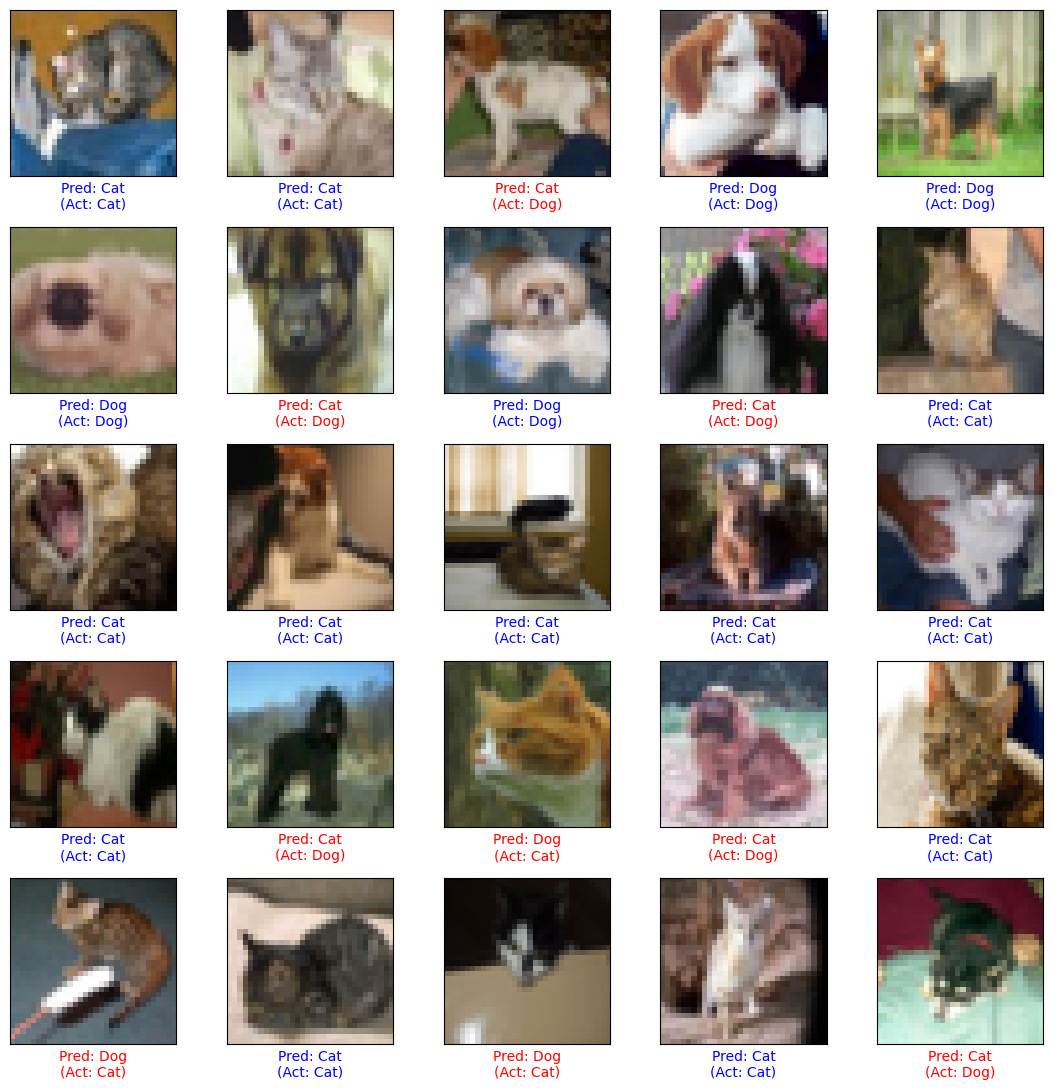

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Tạo thư mục lưu ảnh mẫu
os.makedirs('/content/sample_data', exist_ok=True)

# Cấu hình thiết bị chạy: Ưu tiên GPU (cuda) nếu có
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}\n")

# =====================================================================
# BƯỚC 1: TẢI DỮ LIỆU CIFAR10 VÀ LỌC LẤY ẢNH CHÓ & MÈO
# =====================================================================
print("Đang nạp bộ dữ liệu ảnh màu CIFAR10...")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

# Phẳng hóa mảng nhãn
y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

# Trong bộ dữ liệu CIFAR10: Nhãn 3 là Cat (Mèo), Nhãn 5 là Dog (Chó)
# Chúng ta lọc toàn bộ tập Train để mô hình học cách phân biệt Chó và Mèo
train_mask = (y_train_raw == 3) | (y_train_raw == 5)
X_train_filter = X_train_raw[train_mask]
y_train_filter = y_train_raw[train_mask]

# Lọc tập Test tương tự để lấy ảnh đi dự đoán
test_mask = (y_test_raw == 3) | (y_test_raw == 5)
X_test_filter = X_test_raw[test_mask]
y_test_filter = y_test_raw[test_mask]

# Chuyển đổi nhãn về dạng nhãn nhị phân: Mèo (3) -> thành số 0, Chó (5) -> thành số 1
y_train_binary = np.where(y_train_filter == 3, 0, 1)
y_test_binary = np.where(y_test_filter == 3, 0, 1)

# Duỗi phẳng ma trận ảnh màu 3D (32x32x3 = 3072 điểm ảnh) thành vector phẳng 1D
X_train_flat = X_train_filter.reshape(X_train_filter.shape[0], 3072).astype('float32')
X_test_flat = X_test_filter.reshape(X_test_filter.shape[0], 3072).astype('float32')

# Chuẩn hóa dải điểm ảnh về dải số thực [0-1] bằng MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Chuyển đổi sang PyTorch Tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_binary, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Đóng gói vào DataLoader để chia Batch huấn luyện
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# =====================================================================
# BƯỚC 2: ĐỊNH NGHĨA MẠNG NEURAL (ANN) PHÂN LOẠI CHÓ VÀ MÈO
# =====================================================================
class DogCatANN(nn.Module):
    def __init__(self):
        super(DogCatANN, self).__init__()
        # Tầng ẩn nhận vào 3072 điểm ảnh, xuất ra 256 nút
        self.hidden = nn.Linear(3072, 256)
        self.relu = nn.ReLU()
        # Tầng đầu ra phân loại 2 lớp (0 là Mèo, 1 là Chó)
        self.output = nn.Linear(256, 2)

        nn.init.uniform_(self.hidden.weight, -0.05, 0.05)
        nn.init.uniform_(self.output.weight, -0.05, 0.05)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model = DogCatANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# =====================================================================
# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH HỌC PHÂN BIỆT CHÓ VÀ MÈO
# =====================================================================
epochs = 15
print("--- Bắt đầu huấn luyện mạng ANN nhận diện Chó & Mèo bằng PyTorch ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {running_loss/total:.4f} | Accuracy: {(correct/total)*100:.2f}%")


# =====================================================================
# BƯỚC 4 (MỤC 3.11): DỰ ĐOÁN & IN LƯỚI 25 ẢNH CHÓ VÀ MÈO NGẪU NHIÊN
# =====================================================================
# Tên nhãn chữ tương ứng với số 0 và 1 mà ta đã quy đổi ở Bước 1
class_names = ['Cat', 'Dog']

model.eval()

# Trích xuất đúng 25 bức ảnh Chó/Mèo đầu tiên từ tập dữ liệu test đã lọc
X_test_25 = X_test_tensor[:25].to(device)
y_test_25 = y_test_binary[:25] # Nhãn gốc thực tế để đối chiếu

with torch.no_grad():
    raw_predictions = model(X_test_25)
    predicted_labels = torch.argmax(raw_predictions, dim=1).cpu().numpy()

# Vẽ lưới ảnh vuông 5x5 hiển thị kết quả
plt.figure(figsize=(11, 11))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Hiển thị ảnh màu gốc CIFAR10 (32x32x3)
    plt.imshow(X_test_filter[i])

    # Kiểm tra xem mô hình đoán đúng Chó/Mèo hay không để nhuộm màu chữ
    if predicted_labels[i] == y_test_25[i]:
        color = 'blue'  # Đoán ĐÚNG -> màu xanh dương
    else:
        color = 'red'   # Đoán SAI -> màu đỏ

    plt.xlabel(f"Pred: {class_names[predicted_labels[i]]}\n(Act: {class_names[y_test_25[i]]})", color=color, fontsize=10)

plt.tight_layout()
print("\n[KẾT QUẢ HIỂN THỊ] Lưới ảnh 25 con Chó & Mèo thực tế:")
plt.show()

Đang sử dụng thiết bị tính toán: cpu

Đang nạp bộ dữ liệu ảnh màu CIFAR10...
--- Bắt đầu huấn luyện mạng ANN nhận diện Chó & Mèo (Có Validation) ---
Epoch [1/15] -> Train Loss: 0.7130 | Train Acc: 53.71% | Val Loss: 0.6960 | Val Acc: 52.80%
Epoch [2/15] -> Train Loss: 0.6734 | Train Acc: 56.89% | Val Loss: 0.6708 | Val Acc: 57.10%
Epoch [3/15] -> Train Loss: 0.6666 | Train Acc: 58.38% | Val Loss: 0.6706 | Val Acc: 57.40%
Epoch [4/15] -> Train Loss: 0.6618 | Train Acc: 59.77% | Val Loss: 0.6691 | Val Acc: 58.60%
Epoch [5/15] -> Train Loss: 0.6580 | Train Acc: 59.58% | Val Loss: 0.6653 | Val Acc: 58.10%
Epoch [6/15] -> Train Loss: 0.6546 | Train Acc: 59.94% | Val Loss: 0.6676 | Val Acc: 57.50%
Epoch [7/15] -> Train Loss: 0.6519 | Train Acc: 60.52% | Val Loss: 0.6699 | Val Acc: 57.90%
Epoch [8/15] -> Train Loss: 0.6500 | Train Acc: 61.02% | Val Loss: 0.6645 | Val Acc: 59.00%
Epoch [9/15] -> Train Loss: 0.6481 | Train Acc: 61.17% | Val Loss: 0.6657 | Val Acc: 58.80%
Epoch [10/15] -> Train 

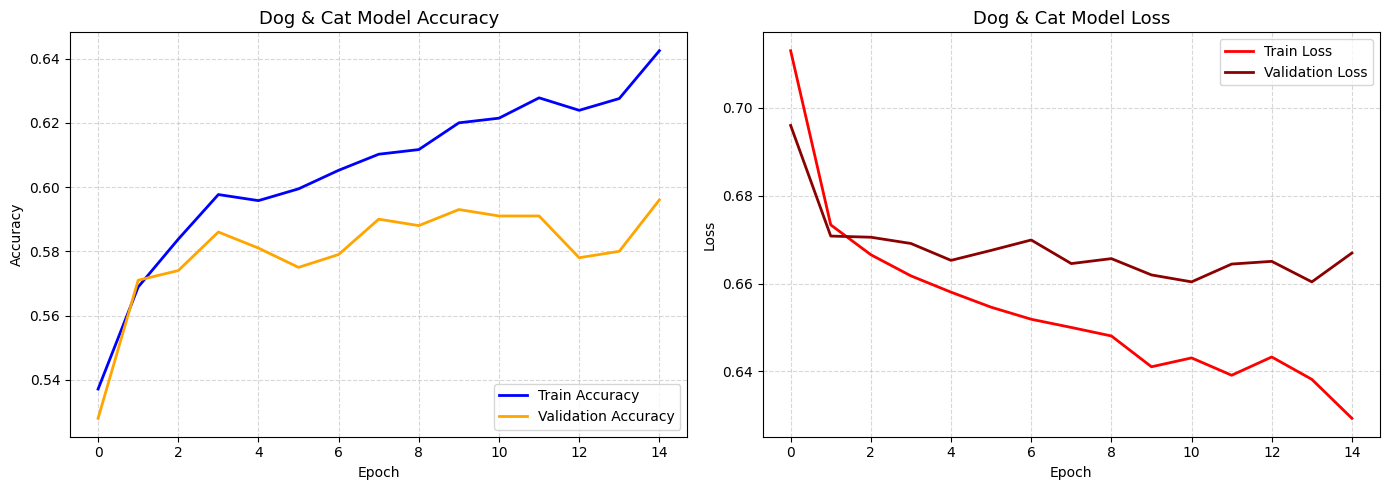


[LƯỚI DỰ ĐOÁN VÀ PHÂN LOẠI 25 HÌNH ẢNH CHÓ & MÈO THỰC TẾ]


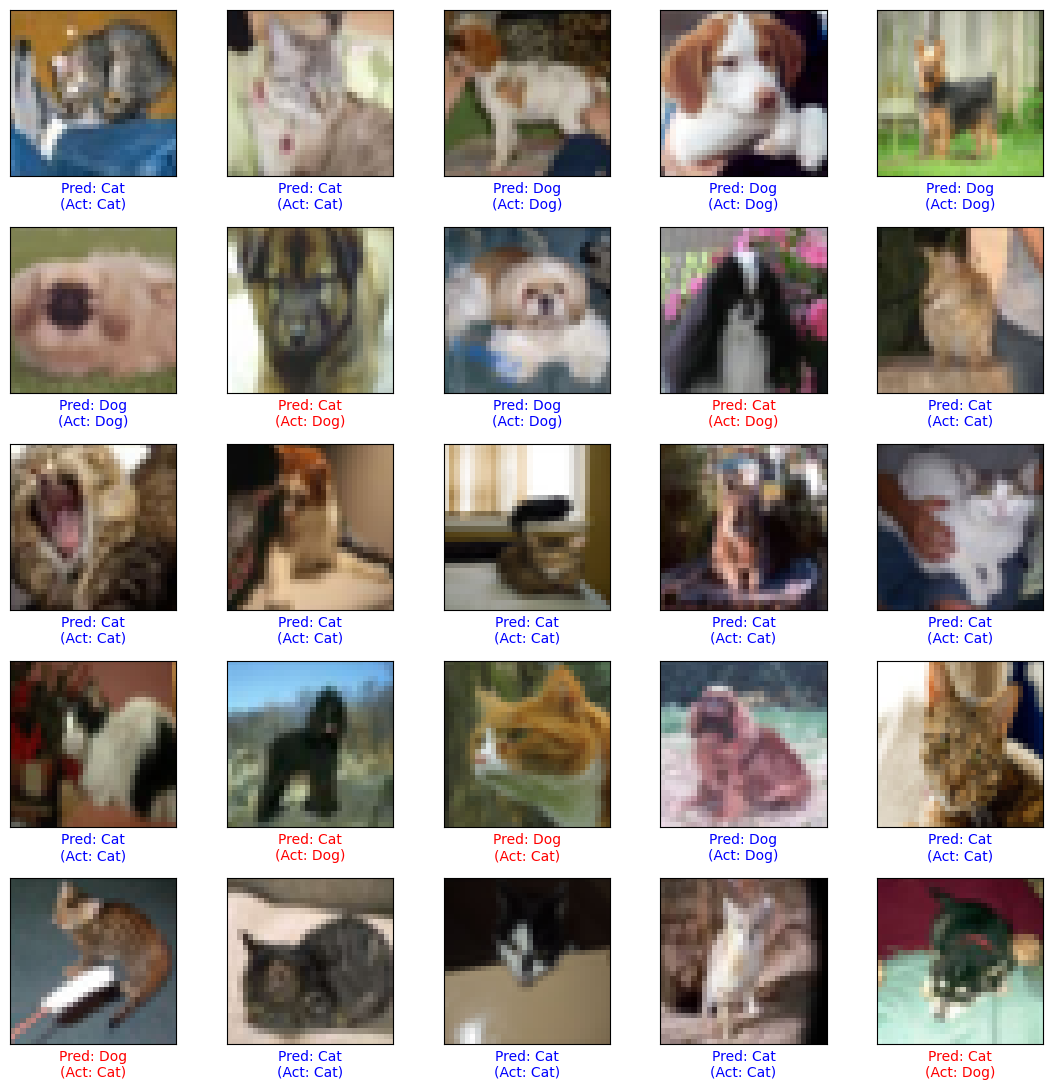

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split # Dùng để tách tập Valid
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

# Tạo thư mục lưu dữ liệu tạm
os.makedirs('/content/sample_data', exist_ok=True)

# Cấu hình thiết bị chạy: Ưu tiên GPU (cuda)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị tính toán: {device}\n")

# =====================================================================
# BƯỚC 1: TẢI DỮ LIỆU CIFAR10 VÀ LỌC LẤY ẢNH CHÓ (5) & MÈO (3)
# =====================================================================
print("Đang nạp bộ dữ liệu ảnh màu CIFAR10...")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()

# Lọc lấy ảnh Chó và Mèo
train_mask = (y_train_raw == 3) | (y_train_raw == 5)
X_train_filter = X_train_raw[train_mask]
y_train_filter = y_train_raw[train_mask]

test_mask = (y_test_raw == 3) | (y_test_raw == 5)
X_test_filter = X_test_raw[test_mask]
y_test_filter = y_test_raw[test_mask]

# Quy đổi nhãn về dạng nhị phân: Mèo -> số 0, Chó -> số 1
y_train_binary = np.where(y_train_filter == 3, 0, 1)
y_test_binary = np.where(y_test_filter == 3, 0, 1)

# Duỗi phẳng ảnh màu 3D (32x32x3) thành dạng vector 1D (3072,)
X_train_flat = X_train_filter.reshape(X_train_filter.shape[0], 3072).astype('float32')
X_test_flat = X_test_filter.reshape(X_test_filter.shape[0], 3072).astype('float32')

# --- CHÚ Ý: TRÍCH XUẤT 10% DỮ LIỆU LÀM TẬP VALIDATION ---
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_flat, y_train_binary, test_size=0.1, random_state=42
)

# Chuẩn hóa dải điểm ảnh về khoảng [0, 1] bằng MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test_flat)

# Đóng gói dữ liệu thành Tensor của PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_split, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Khởi tạo DataLoader cho tập Train
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# =====================================================================
# BƯỚC 2: KHỞI TẠO KIẾN TRÚC MẠNG NEURAL ANN (DOG VÀ CAT)
# =====================================================================
class DogCatANN(nn.Module):
    def __init__(self):
        super(DogCatANN, self).__init__()
        self.hidden = nn.Linear(3072, 256)
        self.relu = nn.ReLU()
        self.output = nn.Linear(256, 2)

        nn.init.uniform_(self.hidden.weight, -0.05, 0.05)
        nn.init.uniform_(self.output.weight, -0.05, 0.05)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model = DogCatANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# =====================================================================
# BƯỚC 3: HUẤN LUYỆN VÀ TÍNH TOÁN SONG SONG CẢ TRAIN VÀ VALIDATION
# =====================================================================
# Khởi tạo history chứa đủ 4 đường dữ liệu để vẽ đồ thị kép
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

epochs = 15
print("--- Bắt đầu huấn luyện mạng ANN nhận diện Chó & Mèo (Có Validation) ---")

for epoch in range(epochs):
    # --- CHẾ ĐỘ HUẤN LUYỆN (TRAIN) ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- CHẾ ĐỘ KIỂM ĐỊNH NỘI BỘ (VALIDATION) ---
    model.eval()
    val_loss_running = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Tắt gradient để chạy nhanh và không phá hỏng trọng số mạng
        # Đẩy dữ liệu tập Valid lên thiết bị GPU/CPU
        X_val_device = X_val_tensor.to(device)
        y_val_device = y_val_tensor.to(device)

        val_outputs = model(X_val_device)
        val_loss_obj = criterion(val_outputs, y_val_device)

        val_loss_running = val_loss_obj.item()
        _, val_predicted = torch.max(val_outputs, 1)
        total_val += y_val_device.size(0)
        correct_val += (val_predicted == y_val_device).sum().item()

    epoch_val_acc = correct_val / total_val

    # Lưu toàn bộ 4 thông số của Epoch này vào cấu trúc lịch sử dữ liệu
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(val_loss_running)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Loss: {val_loss_running:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")


# =====================================================================
# BƯỚC 4: VẼ ĐỒ THỊ KÉP CHỨA ĐỦ 2 ĐƯỜNG TRAIN VÀ VALIDATION (MỤC 3.10)
# =====================================================================
plt.figure(figsize=(14, 5))

# 1. Đồ thị Accuracy đầy đủ 2 đường dữ liệu
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2) # Đường màu cam
plt.title('Dog & Cat Model Accuracy', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Đồ thị Loss đầy đủ 2 đường dữ liệu
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='darkred', linewidth=2) # Đường màu đỏ đậm
plt.title('Dog & Cat Model Loss', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
print("\n[ĐỒ THỊ HIỆU NĂNG HUẤN LUYỆN CHÓ & MÈO ĐẦY ĐỦ 2 ĐƯỜNG DỮ LIỆU]")
plt.show()


# =====================================================================
# BƯỚC 5: DỰ ĐOÁN VÀ HIỂN THỊ LƯỚI 25 ẢNH CHÓ & MÈO (MỤC 3.11)
# =====================================================================
class_names = ['Cat', 'Dog']
model.eval()

# Trích xuất 25 ảnh đầu tiên từ tập test đã lọc Chó/Mèo để đi dự đoán công tâm
X_test_25 = X_test_tensor[:25].to(device)
y_test_25 = y_test_binary[:25]

with torch.no_grad():
    raw_predictions = model(X_test_25)
    predicted_labels = torch.argmax(raw_predictions, dim=1).cpu().numpy()

# Cấu hình lưới hiển thị 25 ảnh vuông 5x5
plt.figure(figsize=(11, 11))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Hiển thị ảnh màu gốc (32x32x3) từ tập dữ liệu đã lọc
    plt.imshow(X_test_filter[i])

    # Kiểm tra đúng/sai để gán màu chữ hiển thị nhãn kết quả
    if predicted_labels[i] == y_test_25[i]:
        color = 'blue'  # Đoán ĐÚNG -> hiển thị chữ màu xanh dương
    else:
        color = 'red'   # Đoán SAI -> hiển thị chữ màu đỏ

    plt.xlabel(f"Pred: {class_names[predicted_labels[i]]}\n(Act: {class_names[y_test_25[i]]})", color=color, fontsize=10)

plt.tight_layout()
print("\n[LƯỚI DỰ ĐOÁN VÀ PHÂN LOẠI 25 HÌNH ẢNH CHÓ & MÈO THỰC TẾ]")
plt.show()

Bài tập 4: dự đoán thu nhập người dùng

Đang sử dụng thiết bị: cpu

-> Đã tự động tạo file dữ liệu thu nhập tại: adult_income_data.csv
   Age  Education-num  Hours-per-week  Income
0   56              3              57       1
1   69              3              59       1
2   46             15              65       1
3   32              9              45       1
4   60              7              37       1 

--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập ---
Epoch [1/30] -> Train Loss: 0.5706 | Train Acc: 71.22% | Val Loss: 0.2507 | Val Acc: 97.00%
Epoch [5/30] -> Train Loss: 0.0393 | Train Acc: 98.78% | Val Loss: 0.0403 | Val Acc: 98.00%
Epoch [10/30] -> Train Loss: 0.0345 | Train Acc: 98.44% | Val Loss: 0.0500 | Val Acc: 97.00%
Epoch [15/30] -> Train Loss: 0.0187 | Train Acc: 99.22% | Val Loss: 0.0327 | Val Acc: 98.00%
Epoch [20/30] -> Train Loss: 0.0187 | Train Acc: 99.11% | Val Loss: 0.0380 | Val Acc: 98.00%
Epoch [25/30] -> Train Loss: 0.0127 | Train Acc: 99.56% | Val Loss: 0.0357 | Val Acc: 98.00%
Epoch [30/30] -> Tr

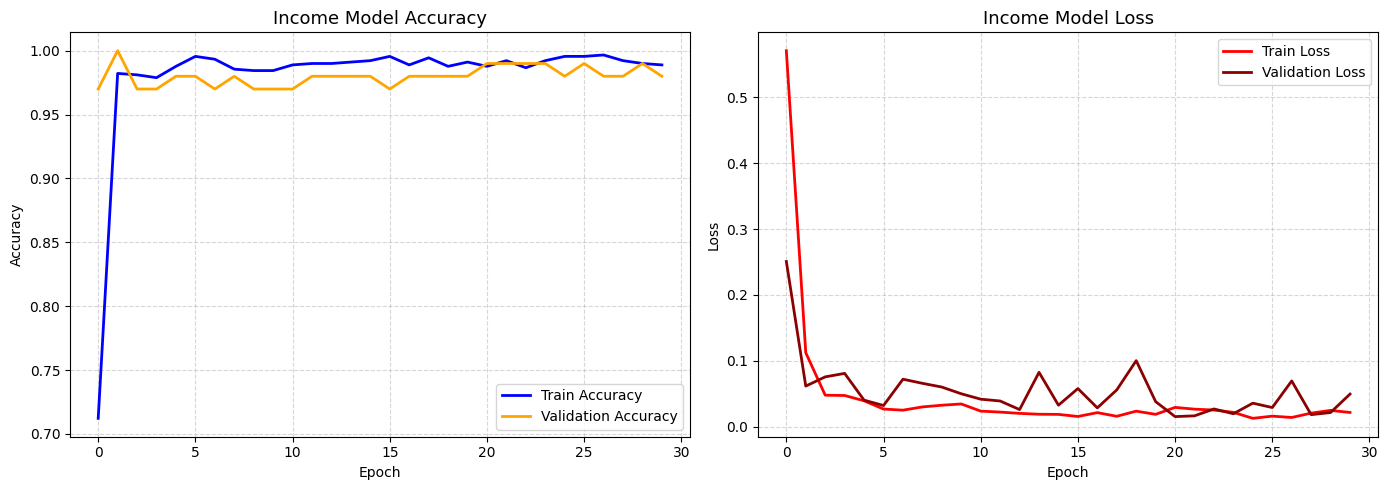


--- TIẾN HÀNH DỰ BÁO THU NHẬP CỦA MỘT NGƯỜI MỚI ---
Thông số nhập vào -> Tuổi: 45.0 | Cấp học vấn: 13.0 | Số giờ làm/tuần: 50.0
Xác suất dự đoán -> <=50K/năm: 0.00% | >50K/năm: 100.00%
==> KẾT LUẬN DỰ BÁO: Người này có mức thu nhập: >50K/năm


In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cấu hình thiết bị tính toán (Ưu tiên GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}\n")

# =====================================================================
# BƯỚC 1: TỰ ĐỘNG TẠO FILE DỮ LIỆU EXCEL/CSV MẪU (BỘ DỮ LIỆU ADULT)
# =====================================================================
# Giả lập dữ liệu thu nhập của 1000 người dùng với các đặc trưng thực tế
np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(18, 70, size=n_samples),
    'Education-num': np.random.randint(1, 16, size=n_samples), # Số năm đi học
    'Hours-per-week': np.random.randint(15, 70, size=n_samples), # Số giờ làm/tuần
}

df = pd.DataFrame(data)

# Tạo logic nhãn thực tế: Nếu tuổi cao, học vấn tốt và làm nhiều giờ -> dễ có thu nhập >50K
# 0 đại diện cho <=50K, 1 đại diện cho >50K
score = df['Age'] * 0.3 + df['Education-num'] * 1.5 + df['Hours-per-week'] * 0.4
df['Income'] = np.where(score > 40, 1, 0)

# Lưu thành file CSV (Bạn có thể mở bằng Excel) đúng theo yêu cầu đề bài
data_path = 'adult_income_data.csv'
df.to_csv(data_path, index=False)
print(f"-> Đã tự động tạo file dữ liệu thu nhập tại: {data_path}")
print(df.head(), "\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU (TÁCH TRAIN/VAL VÀ CHUẨN HÓA DỮ LIỆU)
# =====================================================================
# Đọc dữ liệu từ file vừa tạo
dataset = pd.read_csv(data_path)

# Tách đặc trưng (X) và nhãn cần dự báo (y)
X = dataset[['Age', 'Education-num', 'Hours-per-week']].values.astype(np.float32)
y = dataset['Income'].values.astype(np.int64)

# Tách thành tập Train và Tập Validation theo tỷ lệ 90% - 10% (Giống các bài trước)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Vì các đặc trưng lệch nhau lớn (Tuổi 18-70, Học vấn 1-16), ta dùng StandardScaler để chuẩn hóa dữ liệu số
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)

# Chuyển đổi sang PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_split, dtype=torch.long)

# Đóng gói DataLoader chia theo Batch (Batch size = 32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC MẠNG NEURAL NHÂN TẠO (ANN)
# =====================================================================
class IncomePredictorANN(nn.Module):
    def __init__(self):
        super(IncomePredictorANN, self).__init__()
        # Đầu vào có 3 thuộc tính (Age, Education-num, Hours-per-week)
        self.hidden1 = nn.Linear(3, 64)   # Tầng ẩn 1: 64 neuron
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(64, 32)  # Tầng ẩn 2: 32 neuron (Thêm tầng giúp mạng học thông minh hơn)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(32, 2)    # Tầng đầu ra: 2 neuron (0: <=50K, 1: >50K)

        # Khởi tạo trọng số Uniform theo chuẩn
        nn.init.uniform_(self.hidden1.weight, -0.05, 0.05)
        nn.init.uniform_(self.hidden2.weight, -0.05, 0.05)
        nn.init.uniform_(self.output.weight, -0.05, 0.05)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

model = IncomePredictorANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


# =====================================================================
# BƯỚC 4: VÒNG LẶP HUẤN LUYỆN VÀ GHI LỊCH SỬ ĐỒ THỊ (MỤC 3.10)
# =====================================================================
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

epochs = 30
print("--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập ---")

for epoch in range(epochs):
    # --- CHẾ ĐỘ HUẤN LUYỆN (TRAIN MODE) ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- CHẾ ĐỘ KIỂM ĐỊNH NỘI BỘ (VALIDATION MODE) ---
    model.eval()
    val_loss_running = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        X_val_device = X_val_tensor.to(device)
        y_val_device = y_val_tensor.to(device)

        val_outputs = model(X_val_device)
        val_loss_obj = criterion(val_outputs, y_val_device)

        val_loss_running = val_loss_obj.item()
        _, val_predicted = torch.max(val_outputs, 1)
        total_val += y_val_device.size(0)
        correct_val += (val_predicted == y_val_device).sum().item()

    epoch_val_acc = correct_val / total_val

    # Ghi dữ liệu vào lịch sử đồ thị
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(val_loss_running)
    history['val_acc'].append(epoch_val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Loss: {val_loss_running:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")


# =====================================================================
# BƯỚC 5: VẼ ĐỒ THỊ HIỆU NĂNG 2 ĐƯỜNG TRAIN & VALIDATION (MỤC 3.10)
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị biểu diễn Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Income Model Accuracy', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị biểu diễn Độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Income Model Loss', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
print("\n[ĐỒ THỊ HIỆU NĂNG HUẤN LUYỆN DỰ BÁO THU NHẬP]")
plt.show()


# =====================================================================
# BƯỚC 6 (MỤC 3.11): DỰ ĐOÁN THỬ NGHIỆM TRÊN MỘT NGƯỜI DÙNG MỚI BẤT KỲ
# =====================================================================
print("\n--- TIẾN HÀNH DỰ BÁO THU NHẬP CỦA MỘT NGƯỜI MỚI ---")
class_labels = ['<=50K/năm', '>50K/năm']

# Thông tin người cần dự báo: 45 tuổi, số năm học là 13 (Đại học), làm việc 50 giờ/tuần
person_features = np.array([[45, 13, 50]], dtype=np.float32)

# Bắt buộc phải chuẩn hóa đặc trưng bằng scaler đã fit ở trên trước khi nạp vào mạng PyTorch
person_scaled = scaler.transform(person_features)
person_tensor = torch.tensor(person_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    prediction_raw = model(person_tensor)
    probabilities = torch.softmax(prediction_raw, dim=1).cpu().numpy()[0]
    predicted_class = torch.argmax(prediction_raw, dim=1).item()

print(f"Thông số nhập vào -> Tuổi: {person_features[0][0]} | Cấp học vấn: {person_features[0][1]} | Số giờ làm/tuần: {person_features[0][2]}")
print(f"Xác suất dự đoán -> {class_labels[0]}: {probabilities[0]*100:.2f}% | {class_labels[1]}: {probabilities[1]*100:.2f}%")
print(f"==> KẾT LUẬN DỰ BÁO: Người này có mức thu nhập: {class_labels[predicted_class]}")

bài tập 5: dự bá đánh giá ô tô

Đang sử dụng thiết bị: cpu

-> Đã tạo xong file dữ liệu đánh giá xe tại: car_evaluation_data.csv
  buying  maint  doors persons lug_boot safety  Target
0    med  vhigh      2       2      big    low       0
1    low   high  5more       2      med    med       0
2  vhigh    low      4       4    small   high       1
3    med   high      2    more      med    low       0
4    med  vhigh      4       4    small   high       1 

--- Bắt đầu huấn luyện mạng ANN đánh giá chất lượng xe ---
Epoch [1/35] -> Train Loss: 1.0842 | Train Acc: 54.26% | Val Loss: 0.8694 | Val Acc: 65.00%
Epoch [5/35] -> Train Loss: 0.6132 | Train Acc: 68.43% | Val Loss: 0.5429 | Val Acc: 72.50%
Epoch [10/35] -> Train Loss: 0.2981 | Train Acc: 88.98% | Val Loss: 0.3634 | Val Acc: 83.33%
Epoch [15/35] -> Train Loss: 0.0318 | Train Acc: 100.00% | Val Loss: 0.0320 | Val Acc: 100.00%
Epoch [20/35] -> Train Loss: 0.0088 | Train Acc: 100.00% | Val Loss: 0.0099 | Val Acc: 100.00%
Epoch [25/35] -> Train Loss: 0.0041 | Train A

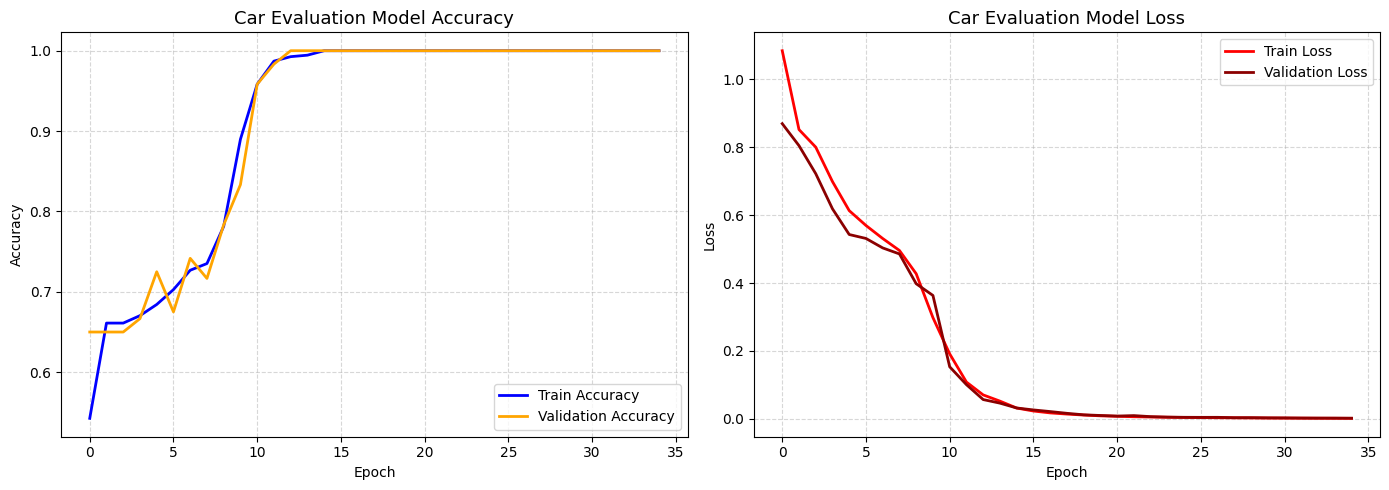


--- TIẾN HÀNH ĐÁNH GIÁ CHẤT LƯỢNG CHO MỘT CHIẾC XE KHÁCH HÀNG ---
Thông số xe nhập vào -> {'buying': 'med', 'maint': 'med', 'doors': '4', 'persons': '4', 'lug_boot': 'big', 'safety': 'high'}
==> KẾT LUẬN DỰ BÁO TỪ MẠNG ANN: Chất lượng xe đạt mức -> good (Xe tốt)
Độ tự tin chi tiết của mô hình: unacc: 0.0% | acc: 0.0% | good: 99.9% | vgood: 0.0%


In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Cấu hình thiết bị tính toán (Ưu tiên GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}\n")

# =====================================================================
# BƯỚC 1: TỰ ĐỘNG TẠO FILE DỮ LIỆU MẪU THEO BỘ DỮ LIỆU CAR EVALUATION
# =====================================================================
np.random.seed(42)
n_samples = 1200

# Tạo dữ liệu ngẫu nhiên dựa trên các thuộc tính chuẩn của bộ dữ liệu Car
data = {
    'buying': np.random.choice(['vhigh', 'high', 'med', 'low'], size=n_samples),
    'maint': np.random.choice(['vhigh', 'high', 'med', 'low'], size=n_samples),
    'doors': np.random.choice(['2', '3', '4', '5more'], size=n_samples),
    'persons': np.random.choice(['2', '4', 'more'], size=n_samples),
    'lug_boot': np.random.choice(['small', 'med', 'big'], size=n_samples),
    'safety': np.random.choice(['low', 'med', 'high'], size=n_samples)
}

df = pd.DataFrame(data)

# Tạo logic nhãn thực tế cho cột cuối (Target): Nếu an toàn cao, giá hợp lý -> Xe tốt (acc/good/vgood)
# Ta phân loại thành 4 mức độ: 0: unacc (Không chấp nhận), 1: acc (Chấp nhận), 2: good (Tốt), 3: vgood (Rất tốt)
def evaluate_car(row):
    if row['safety'] == 'low' or row['persons'] == '2':
        return 0 # unacc
    if row['buying'] in ['vhigh', 'high'] and row['maint'] in ['vhigh', 'high']:
        return 0 # unacc
    if row['safety'] == 'high' and row['buying'] == 'low':
        return 3 # vgood
    if row['safety'] in ['med', 'high'] and row['lug_boot'] in ['med', 'big']:
        return 2 # good
    return 1 # acc

df['Target'] = df.apply(evaluate_car, axis=1)

# Lưu thành file CSV để bạn có thể tải về mở bằng Excel
data_path = 'car_evaluation_data.csv'
df.to_csv(data_path, index=False)
print(f"-> Đã tạo xong file dữ liệu đánh giá xe tại: {data_path}")
print(df.head(), "\n")


# =====================================================================
# BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU (MÃ HÓA CHỮ THÀNH SỐ & TÁCH TẬP TRAIN/VAL)
# =====================================================================
# Đọc file dữ liệu
dataset = pd.read_csv(data_path)

# Vì các cột đầu vào hoàn toàn là dạng chữ (Text), ta dùng LabelEncoder để đổi thành số thực thi
encoders = {}
for col in ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col])
    encoders[col] = le # Lưu lại bộ mã hóa để dùng lúc dự đoán ảnh/xe mới

# Tách ma trận thuộc tính X (6 cột đầu) và nhãn y (cột Target cuối)
X = dataset.iloc[:, :6].values.astype(np.float32)
y = dataset['Target'].values.astype(np.int64)

# Tách dữ liệu thành 90% để Train và 10% để Validation vẽ đồ thị (Mục 3.10)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Chuẩn hóa phân phối dữ liệu số bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)

# Chuyển đổi toàn bộ mảng dữ liệu sang dạng PyTorch Tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_split, dtype=torch.long)

# Đóng gói tập dữ liệu vào DataLoader chia batch (Batch size = 32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# =====================================================================
# BƯỚC 3: XÂY DỰNG KIẾN TRÚC MẠNG NEURAL NHÂN TẠO (ANN) PHÂN LOẠI 4 LỚP
# =====================================================================
class CarEvaluationANN(nn.Module):
    def __init__(self):
        super(CarEvaluationANN, self).__init__()
        # Đầu vào có 6 đặc trưng thuộc tính xe ô tô
        self.hidden1 = nn.Linear(6, 64)   # Tầng ẩn 1: 64 neuron
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(64, 32)  # Tầng ẩn 2: 32 neuron
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(32, 4)    # Tầng đầu ra: 4 neuron đại diện cho 4 mức chất lượng xe (0 đến 3)

        # Khởi tạo trọng số Uniform chuẩn hóa
        nn.init.uniform_(self.hidden1.weight, -0.05, 0.05)
        nn.init.uniform_(self.hidden2.weight, -0.05, 0.05)
        nn.init.uniform_(self.output.weight, -0.05, 0.05)

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

model = CarEvaluationANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


# =====================================================================
# BƯỚC 4: VÒNG LẶP HUẤN LUYỆN VÀ GHI NHẬN 2 ĐƯỜNG TRAIN & VALIDATION
# =====================================================================
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

epochs = 35
print("--- Bắt đầu huấn luyện mạng ANN đánh giá chất lượng xe ---")

for epoch in range(epochs):
    # --- CHẾ ĐỘ HUẤN LUYỆN ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- CHẾ ĐỘ VALIDATION ---
    model.eval()
    val_loss_running = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        X_val_device = X_val_tensor.to(device)
        y_val_device = y_val_tensor.to(device)

        val_outputs = model(X_val_device)
        val_loss_obj = criterion(val_outputs, y_val_device)

        val_loss_running = val_loss_obj.item()
        _, val_predicted = torch.max(val_outputs, 1)
        total_val += y_val_device.size(0)
        correct_val += (val_predicted == y_val_device).sum().item()

    epoch_val_acc = correct_val / total_val

    # Ghi dữ liệu vào lịch sử
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(val_loss_running)
    history['val_acc'].append(epoch_val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Loss: {val_loss_running:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")


# =====================================================================
# BƯỚC 5: V VẼ ĐỒ THỊ HIỆU NĂNG ĐẦY ĐỦ 2 ĐƯỜNG TRAIN VÀ VAL (MỤC 3.10)
# =====================================================================
plt.figure(figsize=(14, 5))

# Đồ thị biểu diễn Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Car Evaluation Model Accuracy', fontsize=13)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị biểu diễn Độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='darkred', linewidth=2)
plt.title('Car Evaluation Model Loss', fontsize=13)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
print("\n[ĐỒ THỊ HIỆU NĂNG HUẤN LUYỆN ĐÁNH GIÁ XE Ô TÔ]")
plt.show()


# =====================================================================
# BƯỚC 6 (MỤC 3.11): ĐƯA RA ĐÁNH GIÁ DỰ BÁO CHO MỘT CHIẾC XE MỚI
# =====================================================================
print("\n--- TIẾN HÀNH ĐÁNH GIÁ CHẤT LƯỢNG CHO MỘT CHIẾC XE KHÁCH HÀNG ---")
target_labels = ['unacc (Không dùng được)', 'acc (Chấp nhận được)', 'good (Xe tốt)', 'vgood (Xe rất tốt)']

# đánh giá thông tin xe: Giá mua: 'med', Bảo dưỡng: 'med', Cửa: '4', Người: '4', Cốp: 'big', An toàn: 'high'
new_car = {
    'buying': 'med', 'maint': 'med', 'doors': '4', 'persons': '4', 'lug_boot': 'big', 'safety': 'high'
}

# 1. Chuyển đổi dữ liệu chữ của chiếc xe mới này sang số dựa vào bộ encoders cũ ở Bước 2
encoded_car_features = []
for col in ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']:
    encoded_val = encoders[col].transform([new_car[col]])[0]
    encoded_car_features.append(encoded_val)

car_array = np.array([encoded_car_features], dtype=np.float32)

# 2. Chuẩn hóa dải số liệu
car_scaled = scaler.transform(car_array)
car_tensor = torch.tensor(car_scaled, dtype=torch.float32).to(device)

# 3. Đưa qua mạng ANN PyTorch dự đoán kết quả đầu ra
model.eval()
with torch.no_grad():
    output_raw = model(car_tensor)
    probabilities = torch.softmax(output_raw, dim=1).cpu().numpy()[0]
    predicted_class = torch.argmax(output_raw, dim=1).item()

print(f"Thông số xe nhập vào -> {new_car}")
print(f"==> KẾT LUẬN DỰ BÁO TỪ MẠNG ANN: Chất lượng xe đạt mức -> {target_labels[predicted_class]}")
print(f"Độ tự tin chi tiết của mô hình: unacc: {probabilities[0]*100:.1f}% | acc: {probabilities[1]*100:.1f}% | good: {probabilities[2]*100:.1f}% | vgood: {probabilities[3]*100:.1f}%")

In [44]:
import pandas as pd

# 1. Đọc lại file dữ liệu CSV vừa được tạo ra
df_visualize = pd.read_csv('car_evaluation_data.csv')

print("=== BẢNG DỮ LIỆU GỐC (ĐỊNH DẠNG TEXT) ===")
print(f"Tổng số dòng trong bảng: {len(df_visualize)} dòng.")
print(f"Danh sách các cột thuộc tính: {list(df_visualize.columns)}\n")

# Hiển thị 10 dòng đầu tiên của bảng dữ liệu gốc dưới dạng bảng chuẩn của Colab
# (Nhãn Target: 0: unacc, 1: acc, 2: good, 3: vgood)
display(df_visualize.head(10))

print("\n" + "="*50 + "\n")

# 2. Xem nhanh thống kê số lượng xe theo từng nhãn chất lượng
print("=== THỐNG KÊ SỐ LƯỢNG XE THEO TỪNG NHÃN (TARGET) ===")
label_mapping = {0: 'unacc', 1: 'acc', 2: 'good', 3: 'vgood'}
distribution = df_visualize['Target'].value_counts().rename(index=label_mapping)
print(distribution)

=== BẢNG DỮ LIỆU GỐC (ĐỊNH DẠNG TEXT) ===
Tổng số dòng trong bảng: 1200 dòng.
Danh sách các cột thuộc tính: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'Target']



,buying,maint,doors,persons,lug_boot,safety,Target
0,med,vhigh,2,2,big,low,0
1,low,high,5more,2,med,med,0
2,vhigh,low,4,4,small,high,1
3,med,high,2,more,med,low,0
4,med,vhigh,4,4,small,high,1
5,low,high,2,more,small,high,3
6,vhigh,vhigh,3,more,small,high,0
7,vhigh,high,4,more,big,high,0
8,med,vhigh,4,more,small,low,0
9,high,vhigh,5more,more,small,low,0




=== THỐNG KÊ SỐ LƯỢNG XE THEO TỪNG NHÃN (TARGET) ===
Target
unacc    792
good     208
acc      134
vgood     66
Name: count, dtype: int64
